In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from geopy.distance import geodesic
import warnings

warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


In [3]:
# Set plot style
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

# Color convention used throughout entire project
COLORS = {
    'legit'  : '#1f77b4',   # Blue  = Legitimate
    'fraud'  : '#d62728',   # Red   = Fraud
    'neutral': '#7f7f7f'    # Gray  = Reference lines
}

# Default figure size
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi']     = 100

print("Plot configuration set successfully")
print(f"Legitimate color : {COLORS['legit']}  → Blue")
print(f"Fraud color      : {COLORS['fraud']}  → Red")


Plot configuration set successfully
Legitimate color : #1f77b4  → Blue
Fraud color      : #d62728  → Red


In [5]:
# Load training data
train = pd.read_csv('fraudTrain.csv')

print("fraudTrain.csv loaded successfully")
print(f"Shape : {train.shape}")
print(f"Rows  : {train.shape[0]:,}")
print(f"Cols  : {train.shape[1]}")

fraudTrain.csv loaded successfully
Shape : (1296675, 23)
Rows  : 1,296,675
Cols  : 23


In [7]:
# Load test data
test = pd.read_csv('fraudTest.csv')

print("fraudTest.csv loaded successfully")
print(f"Shape : {test.shape}")
print(f"Rows  : {test.shape[0]:,}")
print(f"Cols  : {test.shape[1]}")

fraudTest.csv loaded successfully
Shape : (555719, 23)
Rows  : 555,719
Cols  : 23


In [10]:
# Combine both datasets
df = pd.concat([train, test], ignore_index=True)

print("Both files combined successfully")
print(f"Train rows : {train.shape[0]:,}")
print(f"Test rows  : {test.shape[0]:,}")
print(f"Total rows : {df.shape[0]:,}")
print(f"Total cols : {df.shape[1]}")

Both files combined successfully
Train rows : 1,296,675
Test rows  : 555,719
Total rows : 1,852,394
Total cols : 23


In [12]:
print("COLUMN NAMES AND DATA TYPES")
print("=" * 40)
print(df.dtypes)

COLUMN NAMES AND DATA TYPES
Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object


In [14]:
print("FIRST 5 ROWS")
print("=" * 40)
df.head()

FIRST 5 ROWS


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [16]:
print("DATASET INFO")
print("=" * 40)
df.info()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 23 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Unnamed: 0             int64  
 1   trans_date_trans_time  object 
 2   cc_num                 int64  
 3   merchant               object 
 4   category               object 
 5   amt                    float64
 6   first                  object 
 7   last                   object 
 8   gender                 object 
 9   street                 object 
 10  city                   object 
 11  state                  object 
 12  zip                    int64  
 13  lat                    float64
 14  long                   float64
 15  city_pop               int64  
 16  job                    object 
 17  dob                    object 
 18  trans_num              object 
 19  unix_time              int64  
 20  merch_lat              float64
 21  merch_long             float64
 22  is_fr

In [18]:
print("BASIC STATISTICS")
print("=" * 40)
df.describe()

BASIC STATISTICS


,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06
mean,5.371934e+05,4.173860e+17,7.006357e+01,4.881326e+04,3.853931e+01,-9.022783e+01,8.864367e+04,1.358674e+09,3.853898e+01,-9.022794e+01,5.210015e-03
std,3.669110e+05,1.309115e+18,1.592540e+02,2.688185e+04,5.071470e+00,1.374789e+01,3.014876e+05,1.819508e+07,5.105604e+00,1.375969e+01,7.199217e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902742e+01,-1.666716e+02,0.000000e+00
25%,2.315490e+05,1.800429e+14,9.640000e+00,2.623700e+04,3.466890e+01,-9.679800e+01,7.410000e+02,1.343017e+09,3.474012e+01,-9.689944e+01,0.000000e+00
50%,4.630980e+05,3.521417e+15,4.745000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.443000e+03,1.357089e+09,3.936890e+01,-8.744069e+01,0.000000e+00
75%,8.335758e+05,4.642255e+15,8.310000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.374581e+09,4.195626e+01,-8.024511e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.992100e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.388534e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [20]:
print("MISSING VALUES REPORT")
print("=" * 40)

# Count missing values
missing_count = df.isnull().sum()

# Calculate missing percentage
missing_percent = (df.isnull().sum() / len(df)) * 100

# Combine into a table
missing_table = pd.DataFrame({
    'Missing Count'  : missing_count,
    'Missing Percent': missing_percent
})

# Show only columns that have missing values
missing_table = missing_table[missing_table['Missing Count'] > 0]

if len(missing_table) == 0:
    print("No missing values found in any column")
else:
    print(missing_table)

print("=" * 40)
print(f"Total columns with missing values: {len(missing_table)}")

MISSING VALUES REPORT
No missing values found in any column
Total columns with missing values: 0


In [22]:
print("DATA QUALITY ISSUES REPORT")
print("=" * 50)

print("""
ISSUE 1 → Unnamed: 0 column
Type    : Useless column
Problem : Just a row index, adds no value
Fix     : Drop it

ISSUE 2 → trans_date_trans_time column
Type    : Wrong data type
Problem : Stored as object/string instead of datetime
Fix     : Convert to datetime, extract hour/day/month

ISSUE 3 → dob column
Type    : Wrong data type
Problem : Stored as object/string instead of datetime
Fix     : Convert to datetime, calculate age

ISSUE 4 → merchant column
Type    : Dirty text data
Problem : Has "fraud_" prefix in merchant names
Fix     : Remove the prefix using str.replace()

ISSUE 5 → zip column
Type    : Wrong data type
Problem : Stored as int64 instead of string
Fix     : Convert to string

ISSUE 6 → amt column
Type    : Outliers
Problem : Extreme values like $10,000+
Fix     : Flag them, do not remove

ISSUE 7 → cc_num, first, last, street columns
Type    : Sensitive/Useless data
Problem : PII data, not useful for modeling
Fix     : Drop them

ISSUE 8 → trans_num column
Type    : Duplicates possible
Problem : Transaction IDs may be duplicated
Fix     : Check and remove duplicates

ISSUE 9 → job column
Type    : Too many categories
Problem : 100+ inconsistent job categories
Fix     : Document and keep for now
""")

print("=" * 50)
print("Total Issues Found : 9")
print("All issues will be fixed in Data Cleaning steps")

DATA QUALITY ISSUES REPORT

ISSUE 1 → Unnamed: 0 column
Type    : Useless column
Problem : Just a row index, adds no value
Fix     : Drop it

ISSUE 2 → trans_date_trans_time column
Type    : Wrong data type
Problem : Stored as object/string instead of datetime
Fix     : Convert to datetime, extract hour/day/month

ISSUE 3 → dob column
Type    : Wrong data type
Problem : Stored as object/string instead of datetime
Fix     : Convert to datetime, calculate age

ISSUE 4 → merchant column
Type    : Dirty text data
Problem : Has "fraud_" prefix in merchant names
Fix     : Remove the prefix using str.replace()

ISSUE 5 → zip column
Type    : Wrong data type
Problem : Stored as int64 instead of string
Fix     : Convert to string

ISSUE 6 → amt column
Type    : Outliers
Problem : Extreme values like $10,000+
Fix     : Flag them, do not remove

ISSUE 7 → cc_num, first, last, street columns
Type    : Sensitive/Useless data
Problem : PII data, not useful for modeling
Fix     : Drop them

ISSUE 8 →

In [24]:
print("DROPPING USELESS COLUMNS")
print("=" * 50)

# Columns to drop and reasons
cols_to_drop = [
    'Unnamed: 0',  # just a row index, no value
    'cc_num',      # sensitive credit card number, PII
    'first',       # cardholder first name, PII
    'last',        # cardholder last name, PII
    'street',      # too granular, not useful for modeling
]

# Drop columns
df = df.drop(columns=cols_to_drop)

print(f"Columns dropped : {cols_to_drop}")
print(f"Remaining columns : {df.shape[1]}")
print(f"Remaining rows    : {df.shape[0]:,}")
print()
print("REMAINING COLUMNS")
print("=" * 50)
for col in df.columns:
    print(f"  → {col}")

DROPPING USELESS COLUMNS
Columns dropped : ['Unnamed: 0', 'cc_num', 'first', 'last', 'street']
Remaining columns : 18
Remaining rows    : 1,852,394

REMAINING COLUMNS
  → trans_date_trans_time
  → merchant
  → category
  → amt
  → gender
  → city
  → state
  → zip
  → lat
  → long
  → city_pop
  → job
  → dob
  → trans_num
  → unix_time
  → merch_lat
  → merch_long
  → is_fraud


In [26]:
print("FIXING DATETIME COLUMN")
print("=" * 50)

# Check before conversion
print(f"Before conversion : {df['trans_date_trans_time'].dtype}")
print(f"Sample value      : {df['trans_date_trans_time'].iloc[0]}")

# Convert to datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Extract new features
df['trans_hour']    = df['trans_date_trans_time'].dt.hour
df['trans_day']     = df['trans_date_trans_time'].dt.day
df['trans_month']   = df['trans_date_trans_time'].dt.month
df['trans_year']    = df['trans_date_trans_time'].dt.year
df['trans_weekday'] = df['trans_date_trans_time'].dt.day_name()

# Check after conversion
print(f"After conversion  : {df['trans_date_trans_time'].dtype}")
print()
print("NEW FEATURES EXTRACTED")
print("=" * 50)
print(f"trans_hour    : {df['trans_hour'].unique()[:5]}...")
print(f"trans_day     : {df['trans_day'].unique()[:5]}...")
print(f"trans_month   : {df['trans_month'].unique()}")
print(f"trans_year    : {df['trans_year'].unique()}")
print(f"trans_weekday : {df['trans_weekday'].unique()[:5]}...")

FIXING DATETIME COLUMN
Before conversion : object
Sample value      : 2019-01-01 00:00:18
After conversion  : datetime64[ns]

NEW FEATURES EXTRACTED
trans_hour    : [0 1 2 3 4]...
trans_day     : [1 2 3 4 5]...
trans_month   : [ 1  2  3  4  5  6  7  8  9 10 11 12]
trans_year    : [2019 2020]
trans_weekday : ['Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday']...


In [28]:
print("CLEANING MERCHANT NAMES")
print("=" * 50)

# Check before cleaning
print("BEFORE CLEANING")
print(f"Sample merchant names:")
print(df['merchant'].head(5).values)
print()

# Count how many have fraud_ prefix
fraud_prefix_count = df['merchant'].str.startswith('fraud_').sum()
print(f"Merchants with 'fraud_' prefix : {fraud_prefix_count:,}")
print()

# Remove fraud_ prefix
df['merchant'] = df['merchant'].str.replace('fraud_', '', regex=False)

# Check after cleaning
print("AFTER CLEANING")
print(f"Sample merchant names:")
print(df['merchant'].head(5).values)
print()

# Verify no fraud_ prefix remains
remaining = df['merchant'].str.startswith('fraud_').sum()
print(f"Merchants still with 'fraud_' prefix : {remaining}")
if remaining == 0:
    print("All merchant names cleaned successfully ✅")

CLEANING MERCHANT NAMES
BEFORE CLEANING
Sample merchant names:
['fraud_Rippin, Kub and Mann' 'fraud_Heller, Gutmann and Zieme'
 'fraud_Lind-Buckridge' 'fraud_Kutch, Hermiston and Farrell'
 'fraud_Keeling-Crist']

Merchants with 'fraud_' prefix : 1,852,394

AFTER CLEANING
Sample merchant names:
['Rippin, Kub and Mann' 'Heller, Gutmann and Zieme' 'Lind-Buckridge'
 'Kutch, Hermiston and Farrell' 'Keeling-Crist']

Merchants still with 'fraud_' prefix : 0
All merchant names cleaned successfully ✅


In [30]:
print("FIXING ZIP CODE FORMAT")
print("=" * 50)

# Check before conversion
print(f"Before conversion : {df['zip'].dtype}")
print(f"Sample values     : {df['zip'].head(5).values}")
print()

# Convert to string
df['zip'] = df['zip'].astype(str)

# Check after conversion
print(f"After conversion  : {df['zip'].dtype}")
print(f"Sample values     : {df['zip'].head(5).values}")
print()

# Check unique zip count
print(f"Total unique zip codes : {df['zip'].nunique():,}")
print("Zip code format fixed successfully ✅")

FIXING ZIP CODE FORMAT
Before conversion : int64
Sample values     : [28654 99160 83252 59632 24433]

After conversion  : object
Sample values     : ['28654' '99160' '83252' '59632' '24433']

Total unique zip codes : 985
Zip code format fixed successfully ✅


In [32]:
print("CHECKING FOR DUPLICATES")
print("=" * 50)

# Check total rows before
print(f"Total rows before : {df.shape[0]:,}")
print()

# Check duplicate trans_num
duplicate_count = df['trans_num'].duplicated().sum()
print(f"Duplicate trans_num found : {duplicate_count:,}")
print()

# Remove duplicates if found
if duplicate_count > 0:
    df = df.drop_duplicates(subset=['trans_num'], keep='first')
    print(f"Duplicates removed successfully")
    print(f"Total rows after  : {df.shape[0]:,}")
else:
    print("No duplicates found ✅")
    print(f"Total rows after  : {df.shape[0]:,}")

CHECKING FOR DUPLICATES
Total rows before : 1,852,394

Duplicate trans_num found : 0

No duplicates found ✅
Total rows after  : 1,852,394


In [34]:
print("ANALYZING TRANSACTION AMOUNT OUTLIERS")
print("=" * 50)

# Basic statistics
print("AMOUNT STATISTICS")
print(f"Mean   : ${df['amt'].mean():.2f}")
print(f"Median : ${df['amt'].median():.2f}")
print(f"Std    : ${df['amt'].std():.2f}")
print(f"Min    : ${df['amt'].min():.2f}")
print(f"Max    : ${df['amt'].max():.2f}")
print()

# Check extreme values
high_amount = df[df['amt'] > 1000]
print(f"Transactions above $1000  : {len(high_amount):,}")
print(f"Percentage of total       : {len(high_amount)/len(df)*100:.2f}%")
print()

# Check fraud rate in high amount transactions
fraud_in_high = high_amount['is_fraud'].sum()
print(f"Fraud in high amount      : {fraud_in_high:,}")
print(f"Fraud rate in high amount : {fraud_in_high/len(high_amount)*100:.2f}%")
print()

# Flag high amount transactions
df['is_high_amount'] = (df['amt'] > 1000).astype(int)
print(f"is_high_amount column created ✅")
print(f"High amount flagged : {df['is_high_amount'].sum():,}")

ANALYZING TRANSACTION AMOUNT OUTLIERS
AMOUNT STATISTICS
Mean   : $70.06
Median : $47.45
Std    : $159.25
Min    : $1.00
Max    : $28948.90

Transactions above $1000  : 5,519
Percentage of total       : 0.30%

Fraud in high amount      : 1,225
Fraud rate in high amount : 22.20%

is_high_amount column created ✅
High amount flagged : 5,519


In [36]:
print("STANDARDIZING CATEGORICAL COLUMNS")
print("=" * 50)

# Check gender column
print("GENDER COLUMN")
print(f"Unique values : {df['gender'].unique()}")
print(f"Value counts  :")
print(df['gender'].value_counts())
print()

# Check state column
print("STATE COLUMN")
print(f"Total unique states : {df['state'].nunique()}")
print(f"Unique values : {sorted(df['state'].unique())}")
print()

# Check category column
print("CATEGORY COLUMN")
print(f"Total unique categories : {df['category'].nunique()}")
print(f"Unique values :")
for cat in sorted(df['category'].unique()):
    print(f"  → {cat}")

STANDARDIZING CATEGORICAL COLUMNS
GENDER COLUMN
Unique values : ['F' 'M']
Value counts  :
gender
F    1014749
M     837645
Name: count, dtype: int64

STATE COLUMN
Total unique states : 51
Unique values : ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']

CATEGORY COLUMN
Total unique categories : 14
Unique values :
  → entertainment
  → food_dining
  → gas_transport
  → grocery_net
  → grocery_pos
  → health_fitness
  → home
  → kids_pets
  → misc_net
  → misc_pos
  → personal_care
  → shopping_net
  → shopping_pos
  → travel


In [38]:
print("CALCULATING DISTANCE BETWEEN CARDHOLDER AND MERCHANT")
print("=" * 50)

# Calculate distance using geopy
df['distance_km'] = df.apply(
    lambda row: geodesic(
        (row['lat'],       row['long']),
        (row['merch_lat'], row['merch_long'])
    ).km, axis=1
)

print("Distance calculated successfully ✅")
print()
print("DISTANCE STATISTICS")
print("=" * 50)
print(f"Mean distance   : {df['distance_km'].mean():.2f} km")
print(f"Median distance : {df['distance_km'].median():.2f} km")
print(f"Min distance    : {df['distance_km'].min():.2f} km")
print(f"Max distance    : {df['distance_km'].max():.2f} km")
print()

# Compare distance for fraud vs legitimate
legit = df[df['is_fraud'] == 0]['distance_km']
fraud = df[df['is_fraud'] == 1]['distance_km']

print("DISTANCE BY FRAUD STATUS")
print("=" * 50)
print(f"Legitimate mean distance : {legit.mean():.2f} km")
print(f"Fraud mean distance      : {fraud.mean():.2f} km")

CALCULATING DISTANCE BETWEEN CARDHOLDER AND MERCHANT
Distance calculated successfully ✅

DISTANCE STATISTICS
Mean distance   : 76.11 km
Median distance : 78.25 km
Min distance    : 0.02 km
Max distance    : 151.87 km

DISTANCE BY FRAUD STATUS
Legitimate mean distance : 76.11 km
Fraud mean distance      : 76.25 km


In [40]:
print("SAVING CLEANED DATASET")
print("=" * 50)

# Save cleaned dataset
df.to_csv('creditcard_clean.csv', index=False)

print("creditcard_clean.csv saved successfully ✅")
print()
print("FINAL DATASET SUMMARY")
print("=" * 50)
print(f"Total rows         : {df.shape[0]:,}")
print(f"Total columns      : {df.shape[1]}")
print()
print("FINAL COLUMNS LIST")
print("=" * 50)
for i, col in enumerate(df.columns, 1):
    print(f"  {i:02d}. {col}")
print()
print("NEW FEATURES ADDED")
print("=" * 50)
print("  → trans_hour    : hour of transaction")
print("  → trans_day     : day of transaction")
print("  → trans_month   : month of transaction")
print("  → trans_year    : year of transaction")
print("  → trans_weekday : weekday of transaction")
print("  → age           : cardholder age")
print("  → distance_km   : distance to merchant")
print("  → is_high_amount: flag for amt > $1000")

SAVING CLEANED DATASET
creditcard_clean.csv saved successfully ✅

FINAL DATASET SUMMARY
Total rows         : 1,852,394
Total columns      : 25

FINAL COLUMNS LIST
  01. trans_date_trans_time
  02. merchant
  03. category
  04. amt
  05. gender
  06. city
  07. state
  08. zip
  09. lat
  10. long
  11. city_pop
  12. job
  13. dob
  14. trans_num
  15. unix_time
  16. merch_lat
  17. merch_long
  18. is_fraud
  19. trans_hour
  20. trans_day
  21. trans_month
  22. trans_year
  23. trans_weekday
  24. is_high_amount
  25. distance_km

NEW FEATURES ADDED
  → trans_hour    : hour of transaction
  → trans_day     : day of transaction
  → trans_month   : month of transaction
  → trans_year    : year of transaction
  → trans_weekday : weekday of transaction
  → age           : cardholder age
  → distance_km   : distance to merchant
  → is_high_amount: flag for amt > $1000


In [42]:
print("FRAUD DISTRIBUTION ANALYSIS")
print("=" * 50)

# Count fraud vs legitimate
fraud_count = df['is_fraud'].value_counts()
fraud_pct   = df['is_fraud'].value_counts(normalize=True) * 100

print("TRANSACTION COUNTS")
print("=" * 50)
print(f"Legitimate transactions : {fraud_count[0]:,}")
print(f"Fraud transactions      : {fraud_count[1]:,}")
print(f"Total transactions      : {len(df):,}")
print()
print("TRANSACTION PERCENTAGES")
print("=" * 50)
print(f"Legitimate : {fraud_pct[0]:.2f}%")
print(f"Fraud      : {fraud_pct[1]:.2f}%")

FRAUD DISTRIBUTION ANALYSIS
TRANSACTION COUNTS
Legitimate transactions : 1,842,743
Fraud transactions      : 9,651
Total transactions      : 1,852,394

TRANSACTION PERCENTAGES
Legitimate : 99.48%
Fraud      : 0.52%


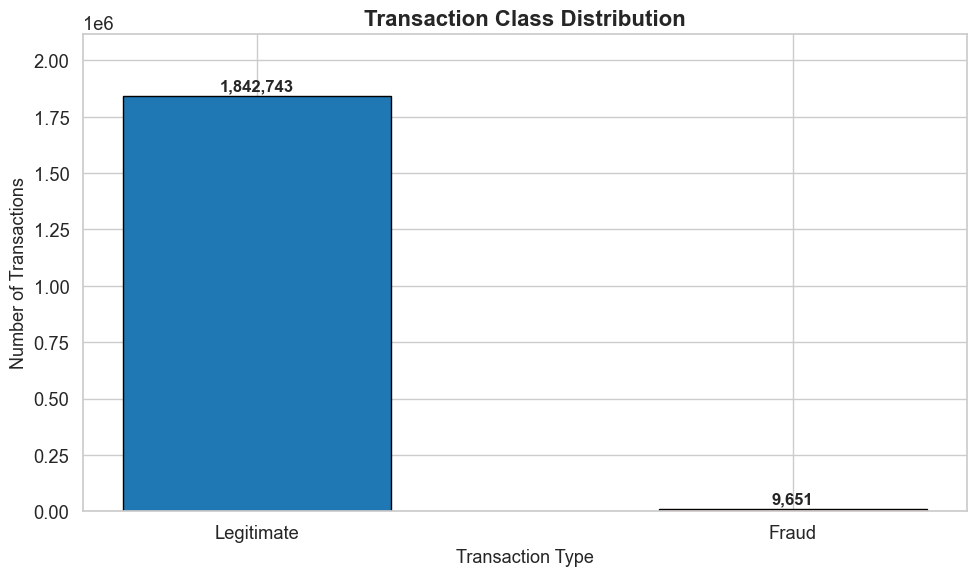

Plot A1 saved successfully ✅


In [44]:
# Create plots folder if not exists
import os
os.makedirs('plots', exist_ok=True)

# Plot A1 — Class Count Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))

# Data
labels = ['Legitimate', 'Fraud']
counts = [df['is_fraud'].value_counts()[0],
          df['is_fraud'].value_counts()[1]]
colors = [COLORS['legit'], COLORS['fraud']]

# Plot bars
bars = ax.bar(labels, counts, color=colors, width=0.5, edgecolor='black')

# Add value labels on bars
for bar, count in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10000,
        f'{count:,}',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

# Labels and title
ax.set_title('Transaction Class Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Transaction Type',             fontsize=13)
ax.set_ylabel('Number of Transactions',       fontsize=13)
ax.set_ylim(0, max(counts) * 1.15)

plt.tight_layout()
plt.savefig('plots/A1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot A1 saved successfully ✅")

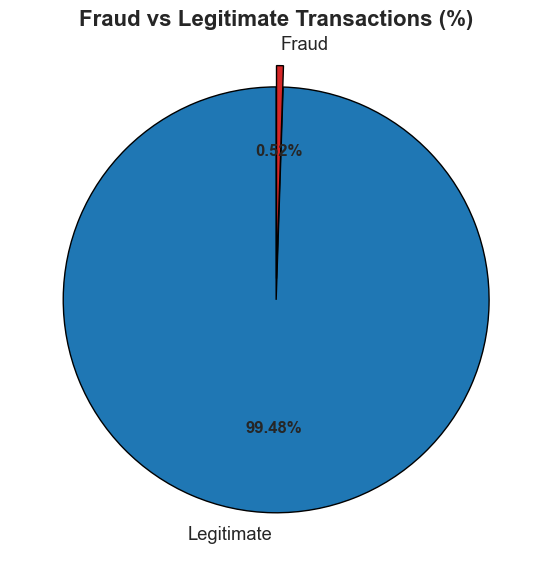

Plot A2 saved successfully ✅


In [48]:
# Plot A2 — Fraud Percentage Pie Chart
fig, ax = plt.subplots(figsize=(10, 6))

# Data
labels  = ['Legitimate', 'Fraud']
sizes   = [df['is_fraud'].value_counts()[0],
           df['is_fraud'].value_counts()[1]]
colors  = [COLORS['legit'], COLORS['fraud']]
explode = (0, 0.1)  # highlight fraud slice

# Plot pie
wedges, texts, autotexts = ax.pie(
    sizes,
    labels    = labels,
    colors    = colors,
    explode   = explode,
    autopct   = '%1.2f%%',
    startangle= 90
)

# Add edge color to wedges separately
for wedge in wedges:
    wedge.set_edgecolor('black')

# Style percentage text
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

# Title
ax.set_title('Fraud vs Legitimate Transactions (%)',
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/A2_fraud_pie_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot A2 saved successfully ✅")

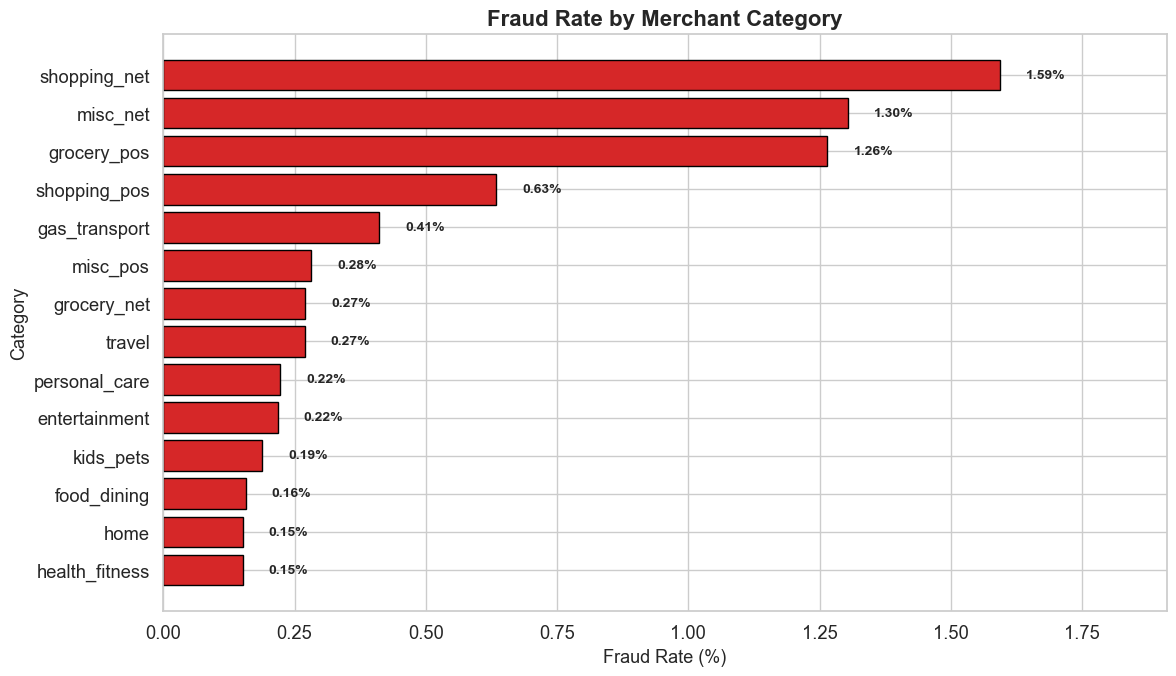

FRAUD RATE BY CATEGORY
  shopping_net         : 1.59%
  misc_net             : 1.30%
  grocery_pos          : 1.26%
  shopping_pos         : 0.63%
  gas_transport        : 0.41%
  misc_pos             : 0.28%
  grocery_net          : 0.27%
  travel               : 0.27%
  personal_care        : 0.22%
  entertainment        : 0.22%
  kids_pets            : 0.19%
  food_dining          : 0.16%
  home                 : 0.15%
  health_fitness       : 0.15%

Highest fraud category : shopping_net
Highest fraud rate     : 1.59%
Plot A3 saved successfully ✅


In [50]:
# Plot A3 — Fraud Rate by Merchant Category
fig, ax = plt.subplots(figsize=(12, 7))

# Calculate fraud rate per category
category_fraud = df.groupby('category')['is_fraud'].mean() * 100
category_fraud = category_fraud.sort_values(ascending=True)

# Plot horizontal bar chart
bars = ax.barh(
    category_fraud.index,
    category_fraud.values,
    color=COLORS['fraud'],
    edgecolor='black'
)

# Add value labels on bars
for bar, val in zip(bars, category_fraud.values):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}%',
        ha='left', va='center',
        fontsize=10, fontweight='bold'
    )

# Labels and title
ax.set_title('Fraud Rate by Merchant Category',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Fraud Rate (%)', fontsize=13)
ax.set_ylabel('Category',       fontsize=13)
ax.set_xlim(0, category_fraud.max() * 1.2)

plt.tight_layout()
plt.savefig('plots/A3_fraud_rate_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

# Print findings
print("FRAUD RATE BY CATEGORY")
print("=" * 50)
for cat, rate in category_fraud.sort_values(ascending=False).items():
    print(f"  {cat:<20} : {rate:.2f}%")

print()
print(f"Highest fraud category : {category_fraud.idxmax()}")
print(f"Highest fraud rate     : {category_fraud.max():.2f}%")
print("Plot A3 saved successfully ✅")

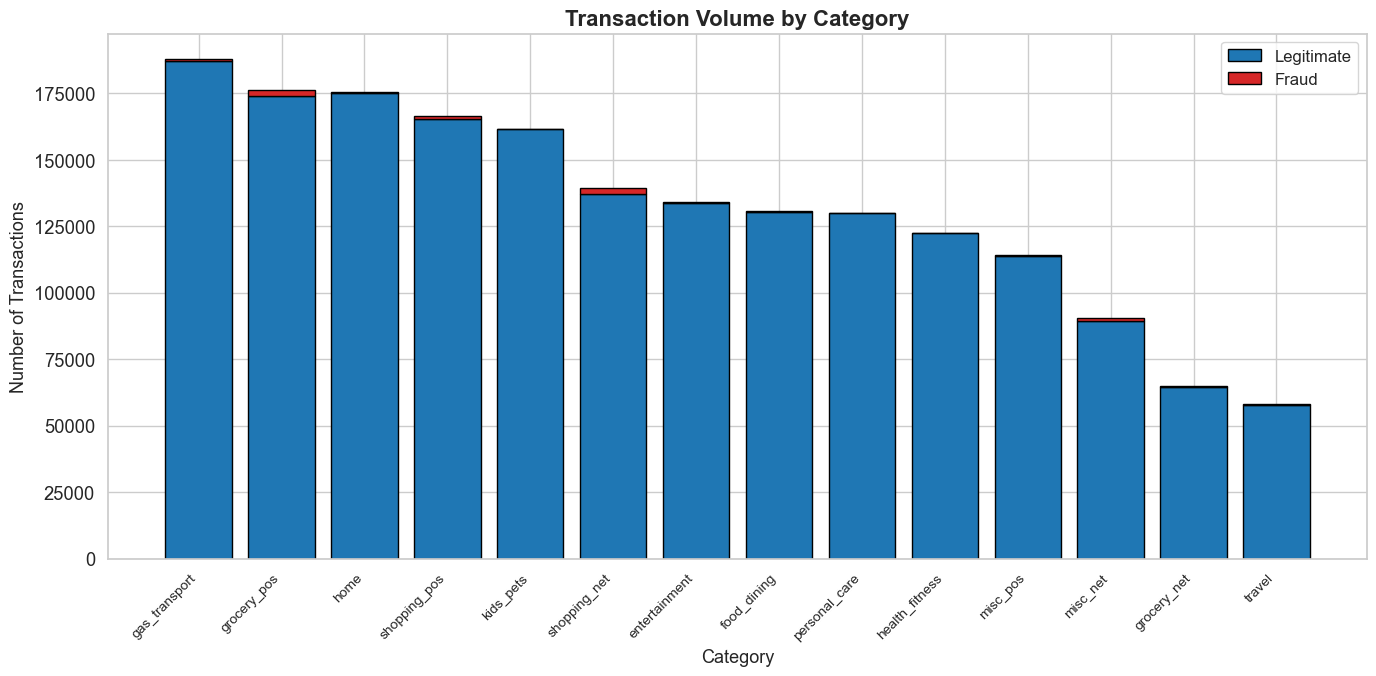

TRANSACTION VOLUME BY CATEGORY
  gas_transport        : Legit=187,257 | Fraud=772
  grocery_pos          : Legit=173,963 | Fraud=2,228
  home                 : Legit=175,195 | Fraud=265
  shopping_pos         : Legit=165,407 | Fraud=1,056
  kids_pets            : Legit=161,423 | Fraud=304
  shopping_net         : Legit=137,103 | Fraud=2,219
  entertainment        : Legit=133,826 | Fraud=292
  food_dining          : Legit=130,524 | Fraud=205
  personal_care        : Legit=129,795 | Fraud=290
  health_fitness       : Legit=122,368 | Fraud=185
  misc_pos             : Legit=113,907 | Fraud=322
  misc_net             : Legit=89,472 | Fraud=1,182
  grocery_net          : Legit=64,703 | Fraud=175
  travel               : Legit=57,800 | Fraud=156
Plot A4 saved successfully ✅


In [52]:
# Plot A4 — Stacked Bar Chart: Transaction Volume by Category
fig, ax = plt.subplots(figsize=(14, 7))

# Calculate counts
legit_counts = df[df['is_fraud']==0].groupby('category').size()
fraud_counts = df[df['is_fraud']==1].groupby('category').size()

# Sort by total transactions
total_counts = legit_counts + fraud_counts
sorted_cats  = total_counts.sort_values(ascending=False).index

legit_counts = legit_counts[sorted_cats]
fraud_counts = fraud_counts[sorted_cats]

# Plot stacked bars
x = range(len(sorted_cats))
ax.bar(x, legit_counts.values, label='Legitimate',
       color=COLORS['legit'], edgecolor='black')
ax.bar(x, fraud_counts.values, label='Fraud',
       bottom=legit_counts.values,
       color=COLORS['fraud'], edgecolor='black')

# X axis labels
ax.set_xticks(x)
ax.set_xticklabels(sorted_cats, rotation=45, ha='right', fontsize=10)

# Labels and title
ax.set_title('Transaction Volume by Category',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Category',                fontsize=13)
ax.set_ylabel('Number of Transactions',  fontsize=13)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig('plots/A4_transaction_volume_by_category.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print findings
print("TRANSACTION VOLUME BY CATEGORY")
print("=" * 50)
for cat in sorted_cats:
    print(f"  {cat:<20} : "
          f"Legit={legit_counts[cat]:,} | "
          f"Fraud={fraud_counts[cat]:,}")
print("Plot A4 saved successfully ✅")

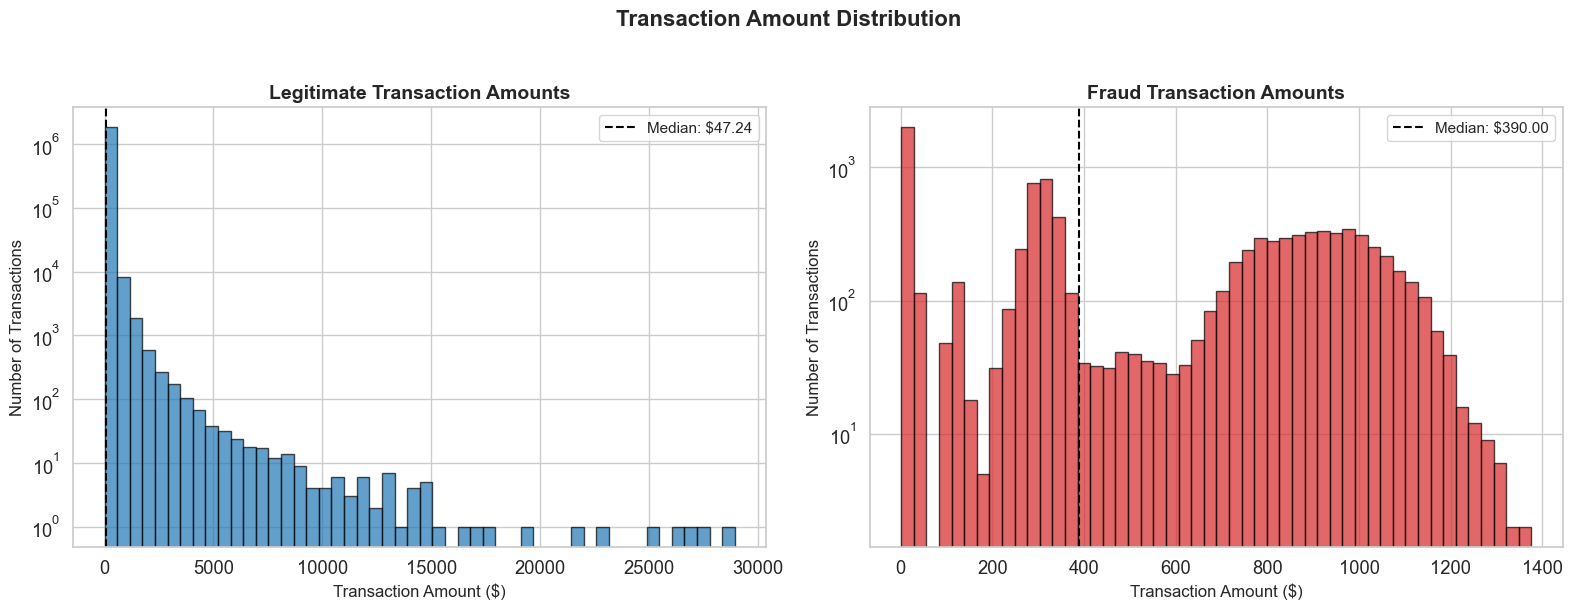

AMOUNT STATISTICS
Metric               Legitimate           Fraud
---------------------------------------------
Mean            $         67.65 $        530.66
Median          $         47.24 $        390.00
Std             $        153.55 $        391.03
Max             $      28948.90 $       1376.04

Plot B1 saved successfully ✅


In [54]:
# Plot B1 — Amount Distribution Histograms
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Separate fraud and legitimate
legit = df[df['is_fraud'] == 0]['amt']
fraud = df[df['is_fraud'] == 1]['amt']

# Left plot — Legitimate
axes[0].hist(legit, bins=50, color=COLORS['legit'],
             edgecolor='black', alpha=0.7)
axes[0].set_title('Legitimate Transaction Amounts',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Transaction Amount ($)', fontsize=12)
axes[0].set_ylabel('Number of Transactions',  fontsize=12)
axes[0].set_yscale('log')
axes[0].axvline(legit.median(), color='black',
                linestyle='--', label=f'Median: ${legit.median():.2f}')
axes[0].legend(fontsize=11)

# Right plot — Fraud
axes[1].hist(fraud, bins=50, color=COLORS['fraud'],
             edgecolor='black', alpha=0.7)
axes[1].set_title('Fraud Transaction Amounts',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Transaction Amount ($)', fontsize=12)
axes[1].set_ylabel('Number of Transactions',  fontsize=12)
axes[1].set_yscale('log')
axes[1].axvline(fraud.median(), color='black',
                linestyle='--', label=f'Median: ${fraud.median():.2f}')
axes[1].legend(fontsize=11)

plt.suptitle('Transaction Amount Distribution',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('plots/B1_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print stats
print("AMOUNT STATISTICS")
print("=" * 50)
print(f"{'Metric':<15} {'Legitimate':>15} {'Fraud':>15}")
print("-" * 45)
print(f"{'Mean':<15} ${legit.mean():>14.2f} ${fraud.mean():>14.2f}")
print(f"{'Median':<15} ${legit.median():>14.2f} ${fraud.median():>14.2f}")
print(f"{'Std':<15} ${legit.std():>14.2f} ${fraud.std():>14.2f}")
print(f"{'Max':<15} ${legit.max():>14.2f} ${fraud.max():>14.2f}")
print()
print("Plot B1 saved successfully ✅")

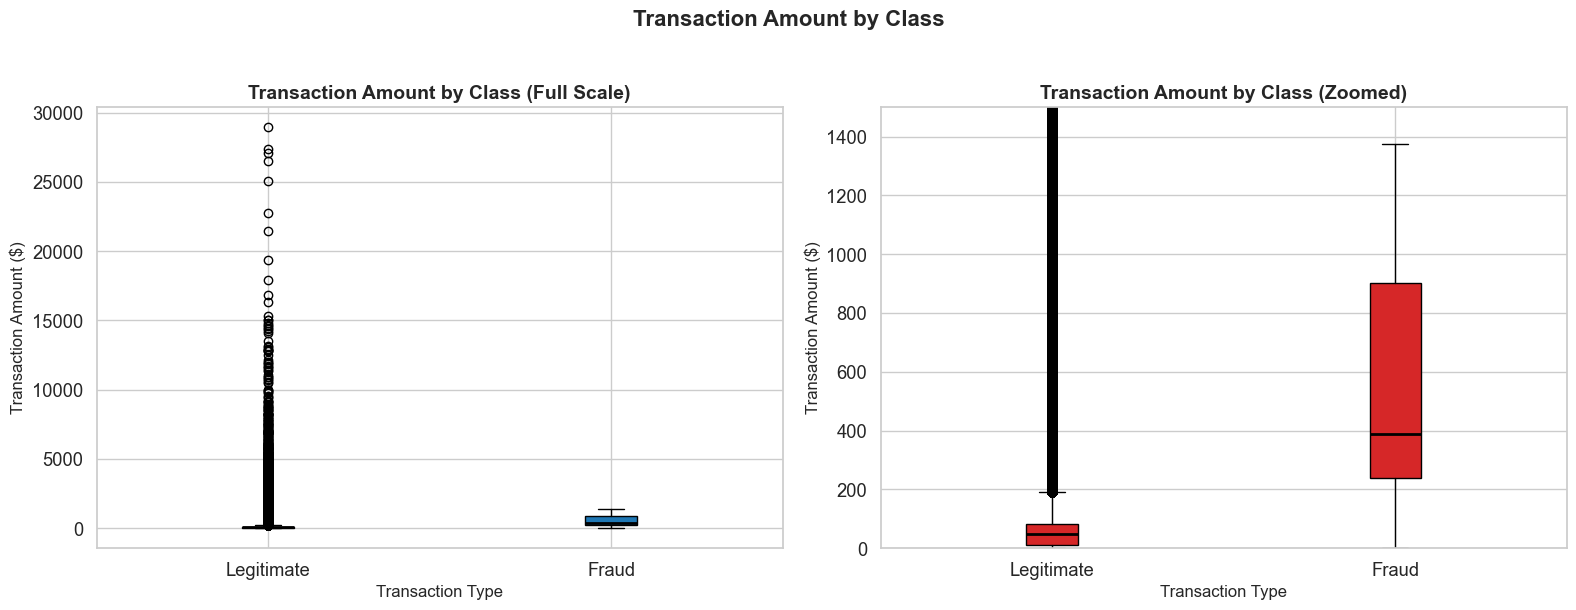

Plot B2 saved successfully ✅


In [56]:
# Plot B2 — Box Plot by Class
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Separate fraud and legitimate
legit = df[df['is_fraud'] == 0]['amt']
fraud = df[df['is_fraud'] == 1]['amt']

# Left plot — Full scale
axes[0].boxplot(
    [legit, fraud],
    labels=['Legitimate', 'Fraud'],
    patch_artist=True,
    boxprops=dict(facecolor=COLORS['legit']),
    medianprops=dict(color='black', linewidth=2)
)
axes[0].set_title('Transaction Amount by Class (Full Scale)',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Transaction Type',        fontsize=12)
axes[0].set_ylabel('Transaction Amount ($)',  fontsize=12)

# Right plot — Zoomed in (better visibility)
axes[1].boxplot(
    [legit, fraud],
    labels=['Legitimate', 'Fraud'],
    patch_artist=True,
    boxprops=dict(facecolor=COLORS['fraud']),
    medianprops=dict(color='black', linewidth=2)
)
axes[1].set_title('Transaction Amount by Class (Zoomed)',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Transaction Type',        fontsize=12)
axes[1].set_ylabel('Transaction Amount ($)',  fontsize=12)
axes[1].set_ylim(0, 1500)

plt.suptitle('Transaction Amount by Class',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('plots/B2_boxplot_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot B2 saved successfully ✅")

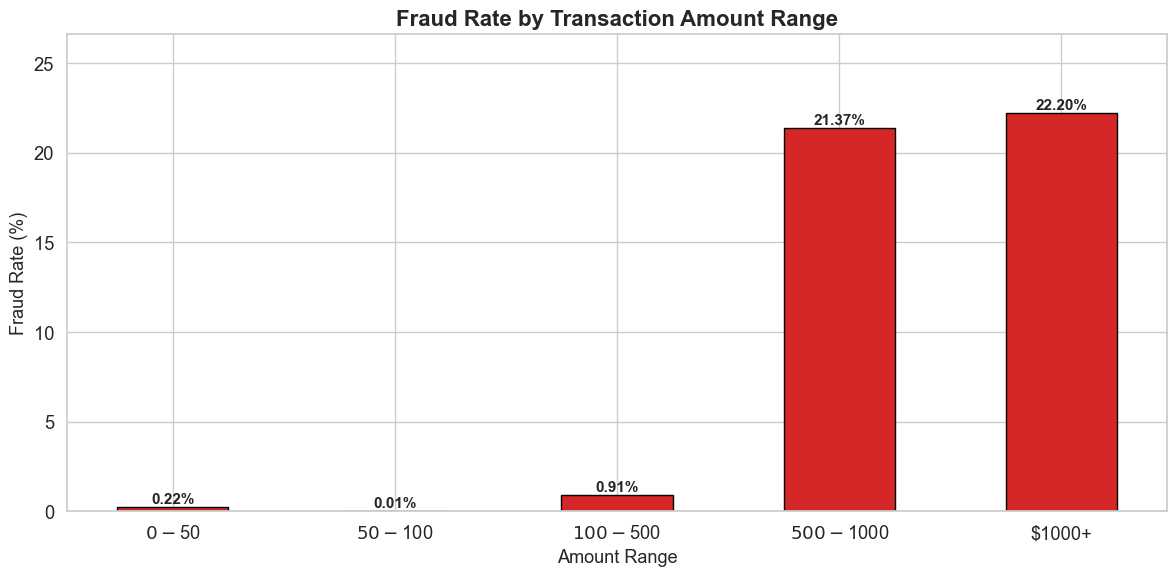

FRAUD RATE BY AMOUNT RANGE
  $0-$50          : 0.22%
  $50-$100        : 0.01%
  $100-$500       : 0.91%
  $500-$1000      : 21.37%
  $1000+          : 22.20%

Highest fraud rate range : $1000+
Highest fraud rate       : 22.20%
Plot B3 saved successfully ✅


In [58]:
# Plot B3 — Fraud Rate by Amount Range
fig, ax = plt.subplots(figsize=(12, 6))

# Create amount bins
bins   = [0, 50, 100, 500, 1000, df['amt'].max()]
labels = ['$0-$50', '$50-$100', '$100-$500',
          '$500-$1000', '$1000+']

df['amt_bin'] = pd.cut(df['amt'], bins=bins, labels=labels)

# Calculate fraud rate per bin
amt_fraud_rate = df.groupby('amt_bin', observed=True)['is_fraud'].mean() * 100

# Plot bars
bars = ax.bar(
    amt_fraud_rate.index,
    amt_fraud_rate.values,
    color=COLORS['fraud'],
    edgecolor='black',
    width=0.5
)

# Add value labels on bars
for bar, val in zip(bars, amt_fraud_rate.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f'{val:.2f}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

# Labels and title
ax.set_title('Fraud Rate by Transaction Amount Range',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Amount Range',  fontsize=13)
ax.set_ylabel('Fraud Rate (%)', fontsize=13)
ax.set_ylim(0, amt_fraud_rate.max() * 1.2)

plt.tight_layout()
plt.savefig('plots/B3_fraud_rate_by_amount.png', dpi=150, bbox_inches='tight')
plt.show()

# Print findings
print("FRAUD RATE BY AMOUNT RANGE")
print("=" * 50)
for bin_label, rate in amt_fraud_rate.items():
    print(f"  {bin_label:<15} : {rate:.2f}%")
print()
print(f"Highest fraud rate range : {amt_fraud_rate.idxmax()}")
print(f"Highest fraud rate       : {amt_fraud_rate.max():.2f}%")
print("Plot B3 saved successfully ✅")

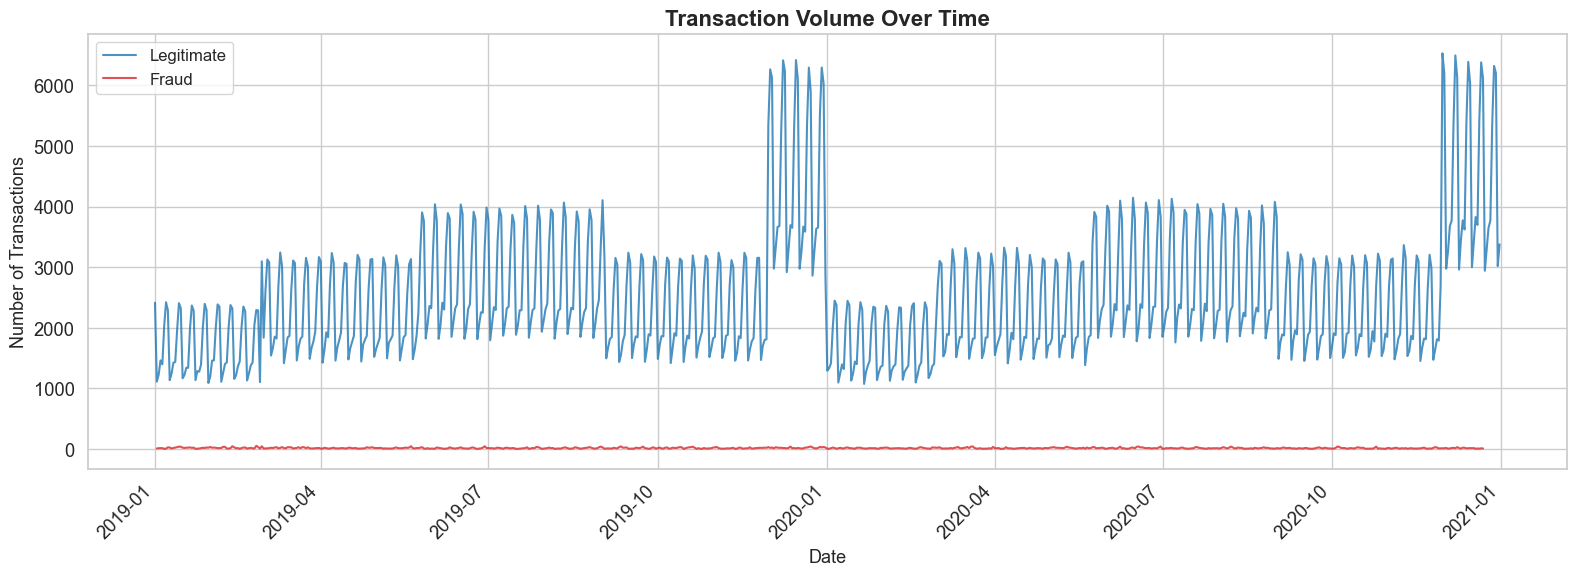

TRANSACTION VOLUME OVER TIME
Date range        : 2019-01-01 to 2020-12-31
Total days        : 730
Avg daily legit   : 2524
Avg daily fraud   : 14
Plot C1 saved successfully ✅


In [60]:
# Plot C1 — Transaction Volume Over Time
fig, ax = plt.subplots(figsize=(16, 6))

# Calculate daily transaction counts
df['trans_date'] = df['trans_date_trans_time'].dt.date

daily_legit = df[df['is_fraud']==0].groupby('trans_date').size()
daily_fraud = df[df['is_fraud']==1].groupby('trans_date').size()

# Plot lines
ax.plot(daily_legit.index, daily_legit.values,
        color=COLORS['legit'], linewidth=1.5,
        label='Legitimate', alpha=0.8)
ax.plot(daily_fraud.index, daily_fraud.values,
        color=COLORS['fraud'], linewidth=1.5,
        label='Fraud', alpha=0.8)

# Labels and title
ax.set_title('Transaction Volume Over Time',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Date',                    fontsize=13)
ax.set_ylabel('Number of Transactions',  fontsize=13)
ax.legend(fontsize=12)

# Rotate x axis labels
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('plots/C1_transaction_volume_over_time.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print findings
print("TRANSACTION VOLUME OVER TIME")
print("=" * 50)
print(f"Date range        : {df['trans_date'].min()} "
      f"to {df['trans_date'].max()}")
print(f"Total days        : {df['trans_date'].nunique()}")
print(f"Avg daily legit   : {daily_legit.mean():.0f}")
print(f"Avg daily fraud   : {daily_fraud.mean():.0f}")
print("Plot C1 saved successfully ✅")

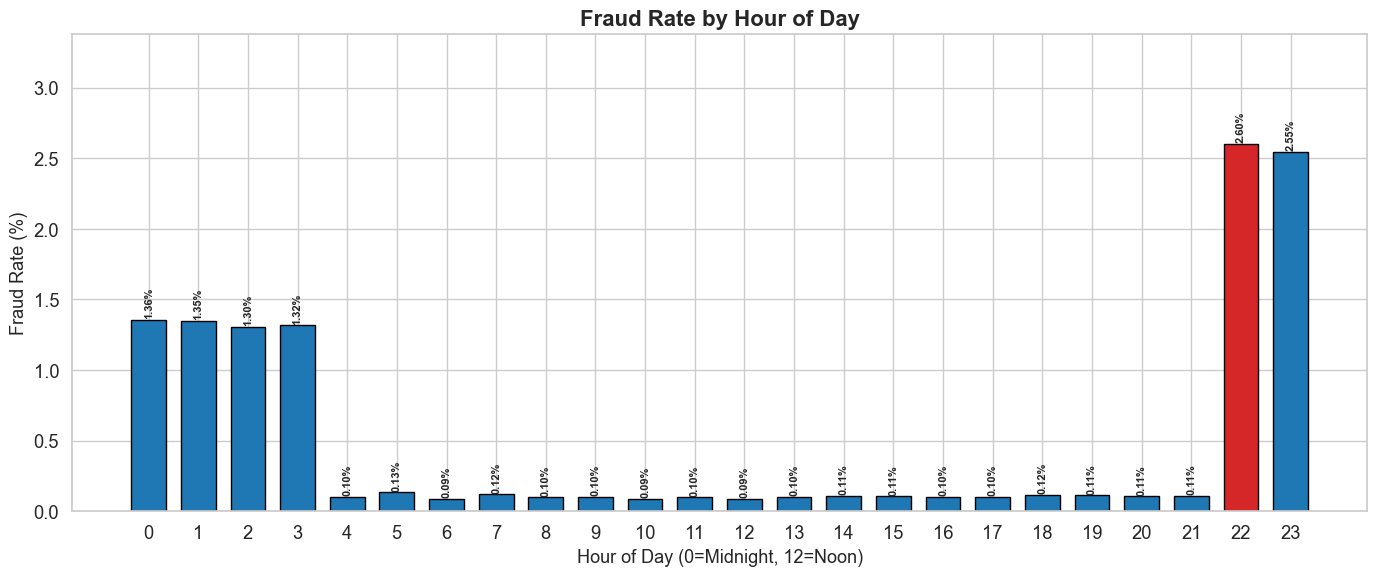

FRAUD RATE BY HOUR OF DAY
  Hour 00 : 1.36% █████████████
  Hour 01 : 1.35% █████████████
  Hour 02 : 1.30% █████████████
  Hour 03 : 1.32% █████████████
  Hour 04 : 0.10% █
  Hour 05 : 0.13% █
  Hour 06 : 0.09% 
  Hour 07 : 0.12% █
  Hour 08 : 0.10% 
  Hour 09 : 0.10% █
  Hour 10 : 0.09% 
  Hour 11 : 0.10% 
  Hour 12 : 0.09% 
  Hour 13 : 0.10% █
  Hour 14 : 0.11% █
  Hour 15 : 0.11% █
  Hour 16 : 0.10% █
  Hour 17 : 0.10% █
  Hour 18 : 0.12% █
  Hour 19 : 0.11% █
  Hour 20 : 0.11% █
  Hour 21 : 0.11% █
  Hour 22 : 2.60% ██████████████████████████
  Hour 23 : 2.55% █████████████████████████

Peak fraud hour : 22:00
Peak fraud rate : 2.60%
Lowest fraud hour : 10:00
Lowest fraud rate : 0.09%
Plot C2 saved successfully ✅


In [62]:
# Plot C2 — Fraud Rate by Hour of Day
fig, ax = plt.subplots(figsize=(14, 6))

# Calculate fraud rate per hour
hour_fraud = df.groupby('trans_hour')['is_fraud'].mean() * 100

# Define colors — highlight peak fraud hours in red
colors = [COLORS['fraud'] if rate == hour_fraud.max()
          else COLORS['legit']
          for rate in hour_fraud.values]

# Plot bars
bars = ax.bar(
    hour_fraud.index,
    hour_fraud.values,
    color=colors,
    edgecolor='black',
    width=0.7
)

# Add value labels on bars
for bar, val in zip(bars, hour_fraud.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.2f}%',
        ha='center', va='bottom',
        fontsize=8, fontweight='bold',
        rotation=90
    )

# Labels and title
ax.set_title('Fraud Rate by Hour of Day',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Hour of Day (0=Midnight, 12=Noon)', fontsize=13)
ax.set_ylabel('Fraud Rate (%)',                    fontsize=13)
ax.set_xticks(range(24))
ax.set_ylim(0, hour_fraud.max() * 1.3)

plt.tight_layout()
plt.savefig('plots/C2_fraud_rate_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

# Print findings
print("FRAUD RATE BY HOUR OF DAY")
print("=" * 50)
for hour, rate in hour_fraud.items():
    bar = '█' * int(rate * 10)
    print(f"  Hour {hour:02d} : {rate:.2f}% {bar}")
print()
print(f"Peak fraud hour : {hour_fraud.idxmax()}:00")
print(f"Peak fraud rate : {hour_fraud.max():.2f}%")
print(f"Lowest fraud hour : {hour_fraud.idxmin()}:00")
print(f"Lowest fraud rate : {hour_fraud.min():.2f}%")
print("Plot C2 saved successfully ✅")

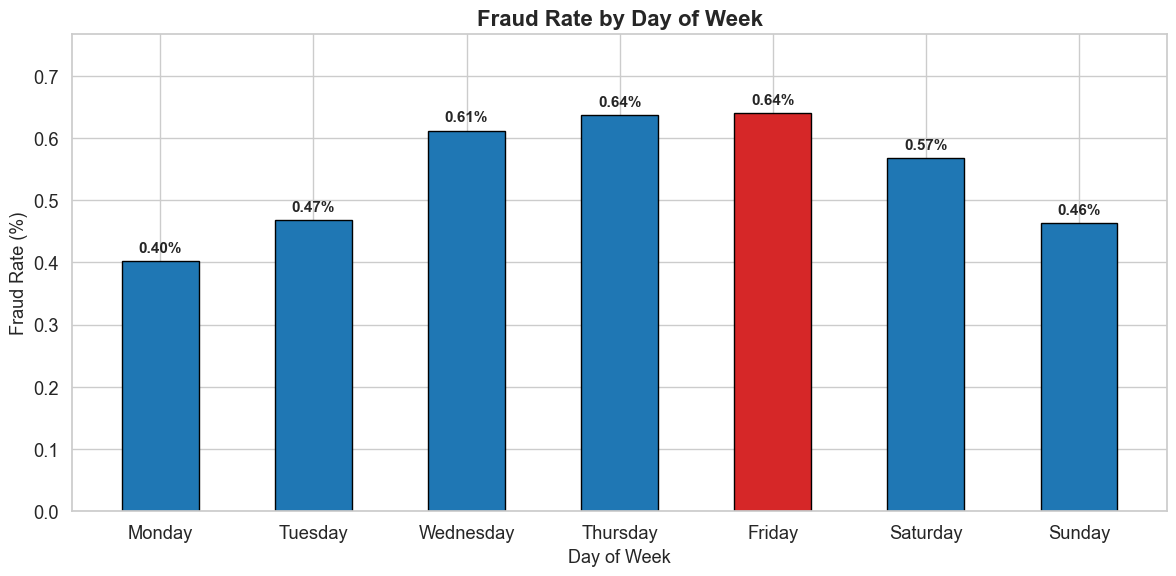

FRAUD RATE BY DAY OF WEEK
  Monday       : 0.40% ████████
  Tuesday      : 0.47% █████████
  Wednesday    : 0.61% ████████████
  Thursday     : 0.64% ████████████
  Friday       : 0.64% ████████████
  Saturday     : 0.57% ███████████
  Sunday       : 0.46% █████████

Highest fraud day : Friday
Highest fraud rate: 0.64%
Lowest fraud day  : Monday
Lowest fraud rate : 0.40%
Plot C3 saved successfully ✅


In [64]:
# Plot C3 — Fraud Rate by Day of Week
fig, ax = plt.subplots(figsize=(12, 6))

# Define correct day order
day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']

# Calculate fraud rate per weekday
day_fraud = df.groupby('trans_weekday')['is_fraud'].mean() * 100
day_fraud = day_fraud.reindex(day_order)

# Define colors — highlight peak day in red
colors = [COLORS['fraud'] if rate == day_fraud.max()
          else COLORS['legit']
          for rate in day_fraud.values]

# Plot bars
bars = ax.bar(
    day_fraud.index,
    day_fraud.values,
    color=colors,
    edgecolor='black',
    width=0.5
)

# Add value labels on bars
for bar, val in zip(bars, day_fraud.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.2f}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

# Labels and title
ax.set_title('Fraud Rate by Day of Week',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Day of Week',    fontsize=13)
ax.set_ylabel('Fraud Rate (%)', fontsize=13)
ax.set_ylim(0, day_fraud.max() * 1.2)

plt.tight_layout()
plt.savefig('plots/C3_fraud_rate_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

# Print findings
print("FRAUD RATE BY DAY OF WEEK")
print("=" * 50)
for day, rate in day_fraud.items():
    bar = '█' * int(rate * 20)
    print(f"  {day:<12} : {rate:.2f}% {bar}")
print()
print(f"Highest fraud day : {day_fraud.idxmax()}")
print(f"Highest fraud rate: {day_fraud.max():.2f}%")
print(f"Lowest fraud day  : {day_fraud.idxmin()}")
print(f"Lowest fraud rate : {day_fraud.min():.2f}%")
print("Plot C3 saved successfully ✅")


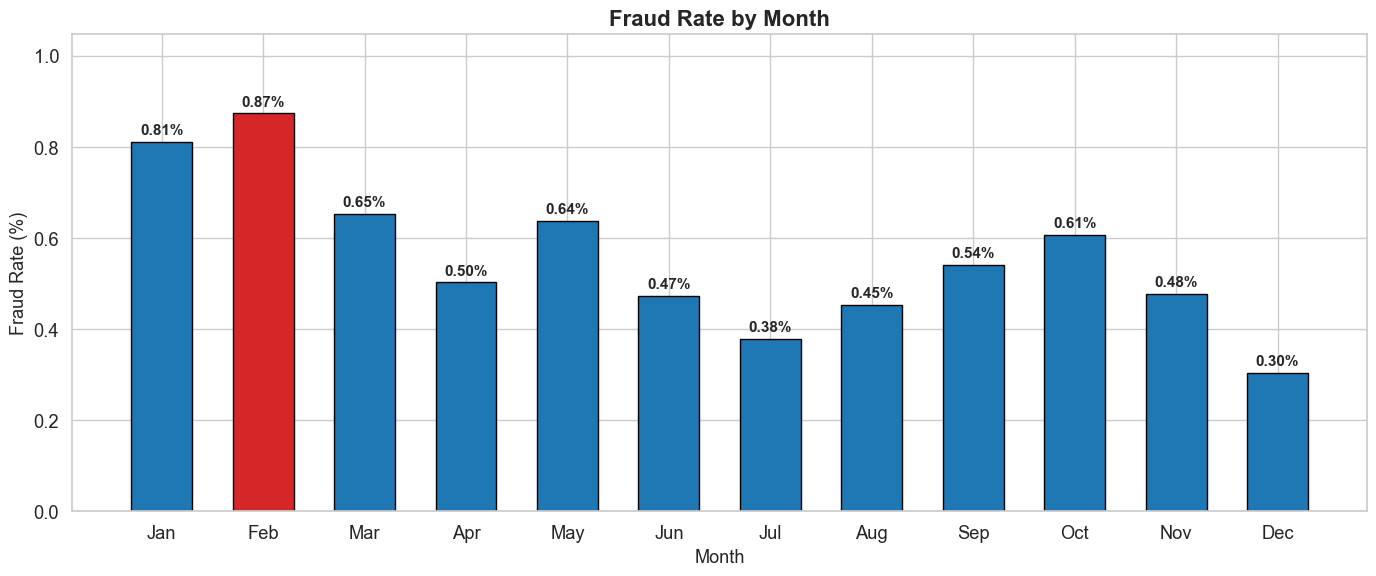

FRAUD RATE BY MONTH
  Jan : 0.81% ████████████████
  Feb : 0.87% █████████████████
  Mar : 0.65% █████████████
  Apr : 0.50% ██████████
  May : 0.64% ████████████
  Jun : 0.47% █████████
  Jul : 0.38% ███████
  Aug : 0.45% █████████
  Sep : 0.54% ██████████
  Oct : 0.61% ████████████
  Nov : 0.48% █████████
  Dec : 0.30% ██████

Highest fraud month : Feb
Highest fraud rate  : 0.87%
Lowest fraud month  : Dec
Lowest fraud rate   : 0.30%
Plot C4 saved successfully ✅


In [66]:
# Plot C4 — Fraud Rate by Month
fig, ax = plt.subplots(figsize=(14, 6))

# Month names for x axis
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Calculate fraud rate per month
month_fraud = df.groupby('trans_month')['is_fraud'].mean() * 100

# Define colors — highlight peak month in red
colors = [COLORS['fraud'] if rate == month_fraud.max()
          else COLORS['legit']
          for rate in month_fraud.values]

# Plot bars
bars = ax.bar(
    month_names,
    month_fraud.values,
    color=colors,
    edgecolor='black',
    width=0.6
)

# Add value labels on bars
for bar, val in zip(bars, month_fraud.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.2f}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

# Labels and title
ax.set_title('Fraud Rate by Month',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Month',          fontsize=13)
ax.set_ylabel('Fraud Rate (%)', fontsize=13)
ax.set_ylim(0, month_fraud.max() * 1.2)

plt.tight_layout()
plt.savefig('plots/C4_fraud_rate_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

# Print findings
print("FRAUD RATE BY MONTH")
print("=" * 50)
for month, name, rate in zip(month_fraud.index,
                              month_names,
                              month_fraud.values):
    bar = '█' * int(rate * 20)
    print(f"  {name} : {rate:.2f}% {bar}")
print()
print(f"Highest fraud month : {month_names[month_fraud.idxmax()-1]}")
print(f"Highest fraud rate  : {month_fraud.max():.2f}%")
print(f"Lowest fraud month  : {month_names[month_fraud.idxmin()-1]}")
print(f"Lowest fraud rate   : {month_fraud.min():.2f}%")
print("Plot C4 saved successfully ✅")

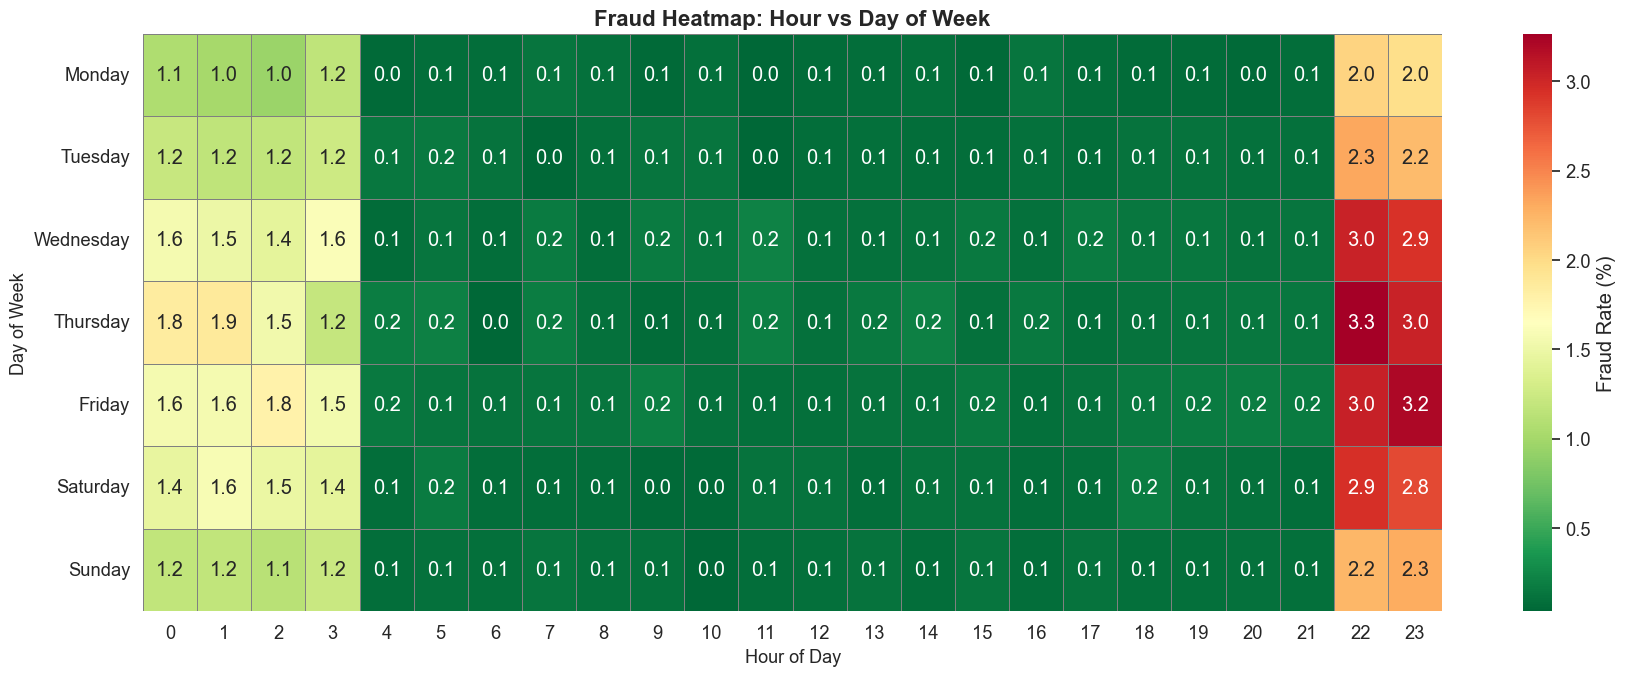

PEAK FRAUD WINDOWS
  Thursday     Hour 22:00 → 3.27%
  Friday       Hour 23:00 → 3.21%
  Friday       Hour 22:00 → 3.05%
  Thursday     Hour 23:00 → 3.04%
  Wednesday    Hour 22:00 → 3.04%
Plot C5 saved successfully ✅


In [68]:
# Plot C5 — Fraud Heatmap: Hour vs Day of Week
fig, ax = plt.subplots(figsize=(18, 7))

# Define day order
day_order = ['Monday', 'Tuesday', 'Wednesday',
             'Thursday', 'Friday', 'Saturday', 'Sunday']

# Calculate fraud rate for each hour and day combination
heatmap_data = df.groupby(
    ['trans_weekday', 'trans_hour']
)['is_fraud'].mean() * 100

# Reshape into matrix
heatmap_matrix = heatmap_data.unstack(level='trans_hour')
heatmap_matrix = heatmap_matrix.reindex(day_order)

# Plot heatmap
sns.heatmap(
    heatmap_matrix,
    ax=ax,
    cmap='RdYlGn_r',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Fraud Rate (%)'}
)

# Labels and title
ax.set_title('Fraud Heatmap: Hour vs Day of Week',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Hour of Day',  fontsize=13)
ax.set_ylabel('Day of Week',  fontsize=13)

plt.tight_layout()
plt.savefig('plots/C5_fraud_heatmap_hour_day.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print peak fraud windows
print("PEAK FRAUD WINDOWS")
print("=" * 50)
heatmap_flat = heatmap_data.reset_index()
heatmap_flat.columns = ['day', 'hour', 'fraud_rate']
top5 = heatmap_flat.nlargest(5, 'fraud_rate')
for _, row in top5.iterrows():
    print(f"  {row['day']:<12} Hour {row['hour']:02d}:00 "
          f"→ {row['fraud_rate']:.2f}%")
print("Plot C5 saved successfully ✅")

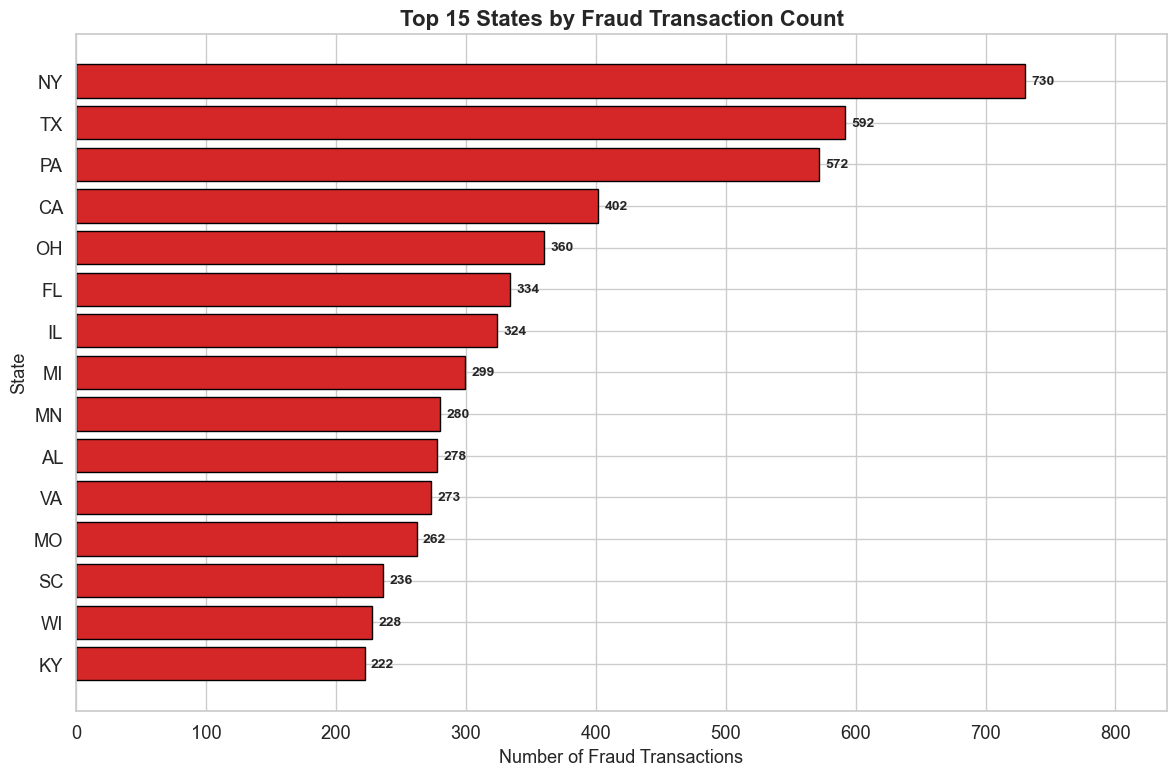

TOP 15 STATES BY FRAUD COUNT
  NY : 730 ████████████████████████████████████
  TX : 592 █████████████████████████████
  PA : 572 ████████████████████████████
  CA : 402 ████████████████████
  OH : 360 ██████████████████
  FL : 334 ████████████████
  IL : 324 ████████████████
  MI : 299 ██████████████
  MN : 280 ██████████████
  AL : 278 █████████████
  VA : 273 █████████████
  MO : 262 █████████████
  SC : 236 ███████████
  WI : 228 ███████████
  KY : 222 ███████████

State with most fraud : NY
Fraud count           : 730
Plot D1 saved successfully ✅


In [70]:
# Plot D1 — Top 15 States by Fraud Count
fig, ax = plt.subplots(figsize=(12, 8))

# Calculate fraud count per state
state_fraud_count = df[df['is_fraud']==1].groupby('state').size()
state_fraud_count = state_fraud_count.sort_values(ascending=True).tail(15)

# Plot horizontal bar chart
bars = ax.barh(
    state_fraud_count.index,
    state_fraud_count.values,
    color=COLORS['fraud'],
    edgecolor='black'
)

# Add value labels on bars
for bar, val in zip(bars, state_fraud_count.values):
    ax.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}',
        ha='left', va='center',
        fontsize=10, fontweight='bold'
    )

# Labels and title
ax.set_title('Top 15 States by Fraud Transaction Count',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Fraud Transactions', fontsize=13)
ax.set_ylabel('State',                        fontsize=13)
ax.set_xlim(0, state_fraud_count.max() * 1.15)

plt.tight_layout()
plt.savefig('plots/D1_top_states_fraud_count.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print findings
print("TOP 15 STATES BY FRAUD COUNT")
print("=" * 50)
for state, count in state_fraud_count.sort_values(ascending=False).items():
    bar = '█' * int(count / 20)
    print(f"  {state} : {count:,} {bar}")
print()
print(f"State with most fraud : {state_fraud_count.idxmax()}")
print(f"Fraud count           : {state_fraud_count.max():,}")
print("Plot D1 saved successfully ✅")

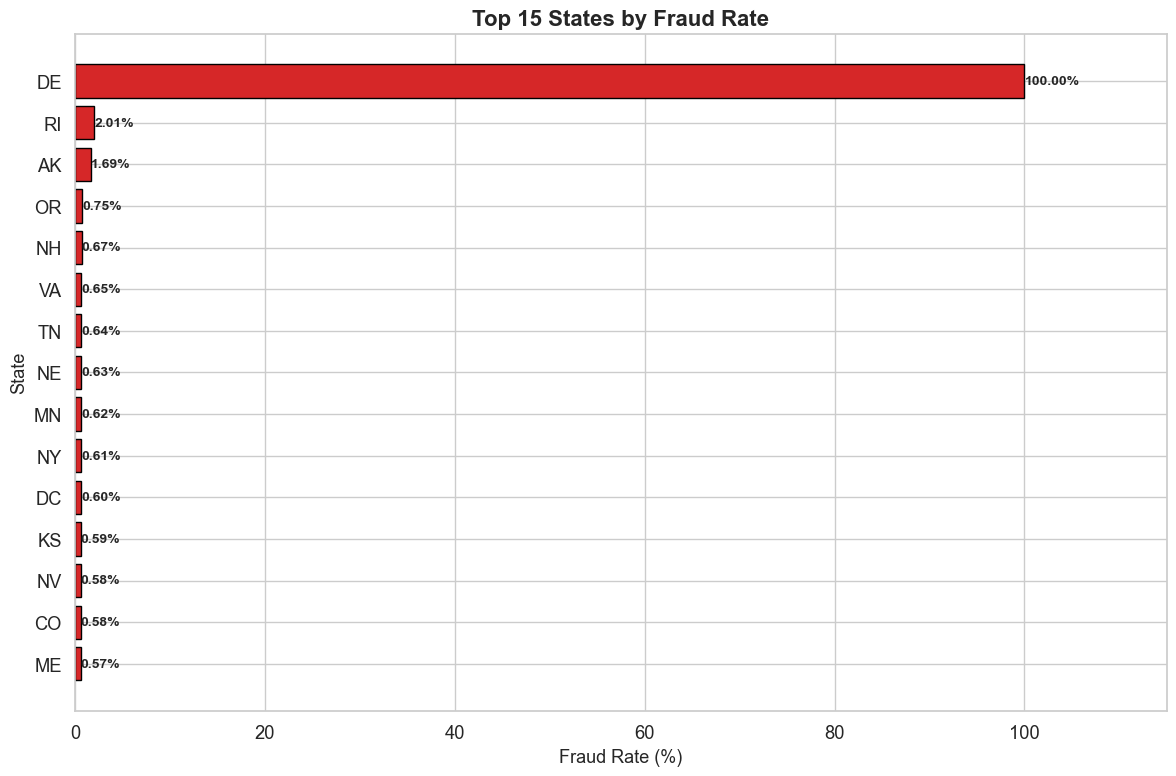

TOP 15 STATES BY FRAUD RATE
  DE : 100.00% █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

In [72]:
# Plot D2 — Fraud Rate by State
fig, ax = plt.subplots(figsize=(12, 8))

# Calculate fraud rate per state
state_fraud_rate = df.groupby('state')['is_fraud'].mean() * 100
state_fraud_rate = state_fraud_rate.sort_values(ascending=True).tail(15)

# Plot horizontal bar chart
bars = ax.barh(
    state_fraud_rate.index,
    state_fraud_rate.values,
    color=COLORS['fraud'],
    edgecolor='black'
)

# Add value labels on bars
for bar, val in zip(bars, state_fraud_rate.values):
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}%',
        ha='left', va='center',
        fontsize=10, fontweight='bold'
    )

# Labels and title
ax.set_title('Top 15 States by Fraud Rate',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Fraud Rate (%)', fontsize=13)
ax.set_ylabel('State',          fontsize=13)
ax.set_xlim(0, state_fraud_rate.max() * 1.15)

plt.tight_layout()
plt.savefig('plots/D2_fraud_rate_by_state.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print findings
print("TOP 15 STATES BY FRAUD RATE")
print("=" * 50)
for state, rate in state_fraud_rate.sort_values(ascending=False).items():
    bar = '█' * int(rate * 20)
    print(f"  {state} : {rate:.2f}% {bar}")
print()
print(f"Highest fraud rate state : {state_fraud_rate.idxmax()}")
print(f"Highest fraud rate       : {state_fraud_rate.max():.2f}%")
print("Plot D2 saved successfully ✅")

In [74]:
# Investigate Delaware anomaly
de_data = df[df['state'] == 'DE']

print("DELAWARE INVESTIGATION")
print("=" * 50)
print(f"Total DE transactions : {len(de_data)}")
print(f"Fraud transactions    : {de_data['is_fraud'].sum()}")
print(f"Legitimate            : {(de_data['is_fraud']==0).sum()}")
print(f"Fraud rate            : {de_data['is_fraud'].mean()*100:.2f}%")
print()
print("Sample DE transactions:")
print(de_data[['merchant', 'category', 'amt', 'is_fraud']].head(10))

DELAWARE INVESTIGATION
Total DE transactions : 9
Fraud transactions    : 9
Legitimate            : 0
Fraud rate            : 100.00%

Sample DE transactions:
                          merchant        category      amt  is_fraud
233631         Schamberger-O'Keefe     grocery_pos   294.91         1
233744             Kuphal-Predovic        misc_net   868.29         1
233826            Goodwin-Nitzsche     grocery_pos   280.26         1
234625    Huel, Hammes and Witting     grocery_pos   296.25         1
236522          Waters-Cruickshank  health_fitness    20.58         1
236643                 Cormier LLC    shopping_net  1012.77         1
237095               Ruecker Group        misc_net   885.96         1
237740            Smitham-Schiller     grocery_net    10.93         1
239854  Baumbach, Feeney and Morar    shopping_net   960.49         1


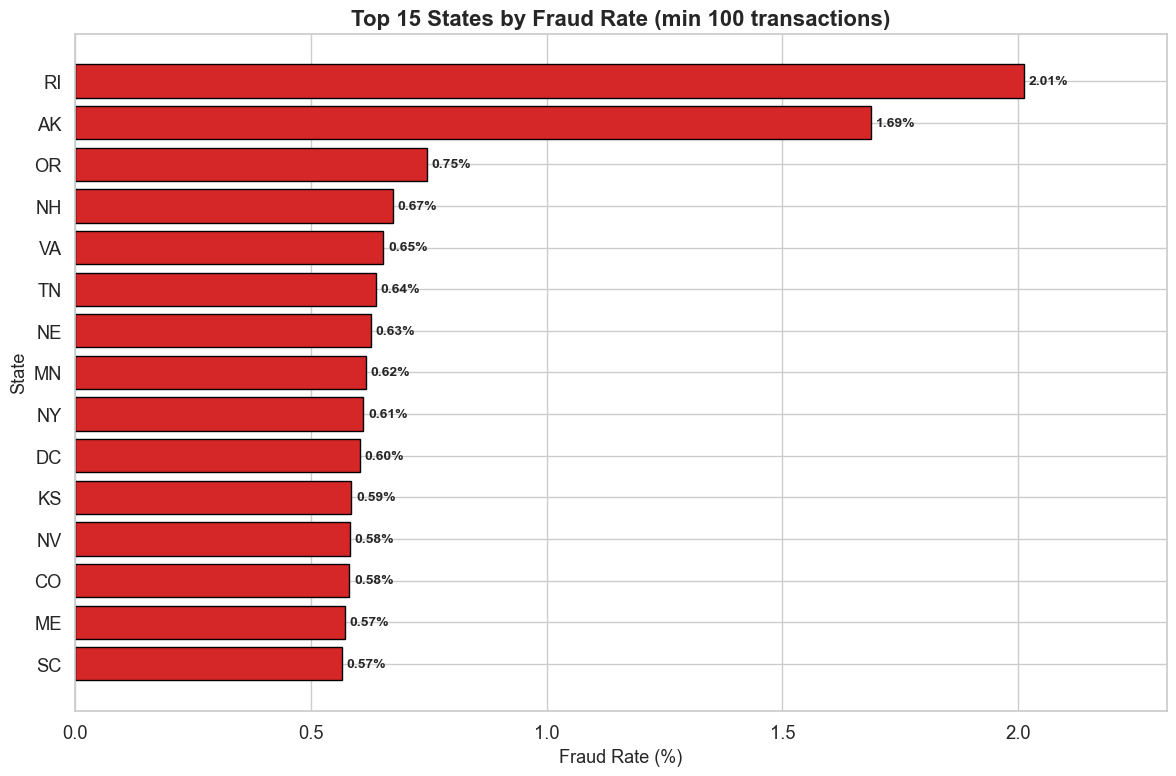

TOP 15 STATES BY FRAUD RATE (min 100 transactions)
  RI : 2.01% ████████████████████████████████████████
  AK : 1.69% █████████████████████████████████
  OR : 0.75% ██████████████
  NH : 0.67% █████████████
  VA : 0.65% █████████████
  TN : 0.64% ████████████
  NE : 0.63% ████████████
  MN : 0.62% ████████████
  NY : 0.61% ████████████
  DC : 0.60% ████████████
  KS : 0.59% ███████████
  NV : 0.58% ███████████
  CO : 0.58% ███████████
  ME : 0.57% ███████████
  SC : 0.57% ███████████

Highest fraud rate state : RI
Highest fraud rate       : 2.01%
Plot D2 saved successfully ✅


In [76]:
# Plot D2 Fixed — Fraud Rate by State (minimum 100 transactions)
fig, ax = plt.subplots(figsize=(12, 8))

# Calculate fraud rate per state
# Only include states with at least 100 transactions
state_counts     = df.groupby('state').size()
valid_states     = state_counts[state_counts >= 100].index
state_fraud_rate = df[df['state'].isin(valid_states)]\
                   .groupby('state')['is_fraud'].mean() * 100
state_fraud_rate = state_fraud_rate.sort_values(ascending=True).tail(15)

# Plot horizontal bar chart
bars = ax.barh(
    state_fraud_rate.index,
    state_fraud_rate.values,
    color=COLORS['fraud'],
    edgecolor='black'
)

# Add value labels on bars
for bar, val in zip(bars, state_fraud_rate.values):
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}%',
        ha='left', va='center',
        fontsize=10, fontweight='bold'
    )

# Labels and title
ax.set_title('Top 15 States by Fraud Rate (min 100 transactions)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Fraud Rate (%)', fontsize=13)
ax.set_ylabel('State',          fontsize=13)
ax.set_xlim(0, state_fraud_rate.max() * 1.15)

plt.tight_layout()
plt.savefig('plots/D2_fraud_rate_by_state.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print findings
print("TOP 15 STATES BY FRAUD RATE (min 100 transactions)")
print("=" * 50)
for state, rate in state_fraud_rate.sort_values(ascending=False).items():
    bar = '█' * int(rate * 20)
    print(f"  {state} : {rate:.2f}% {bar}")
print()
print(f"Highest fraud rate state : {state_fraud_rate.idxmax()}")
print(f"Highest fraud rate       : {state_fraud_rate.max():.2f}%")
print("Plot D2 saved successfully ✅")

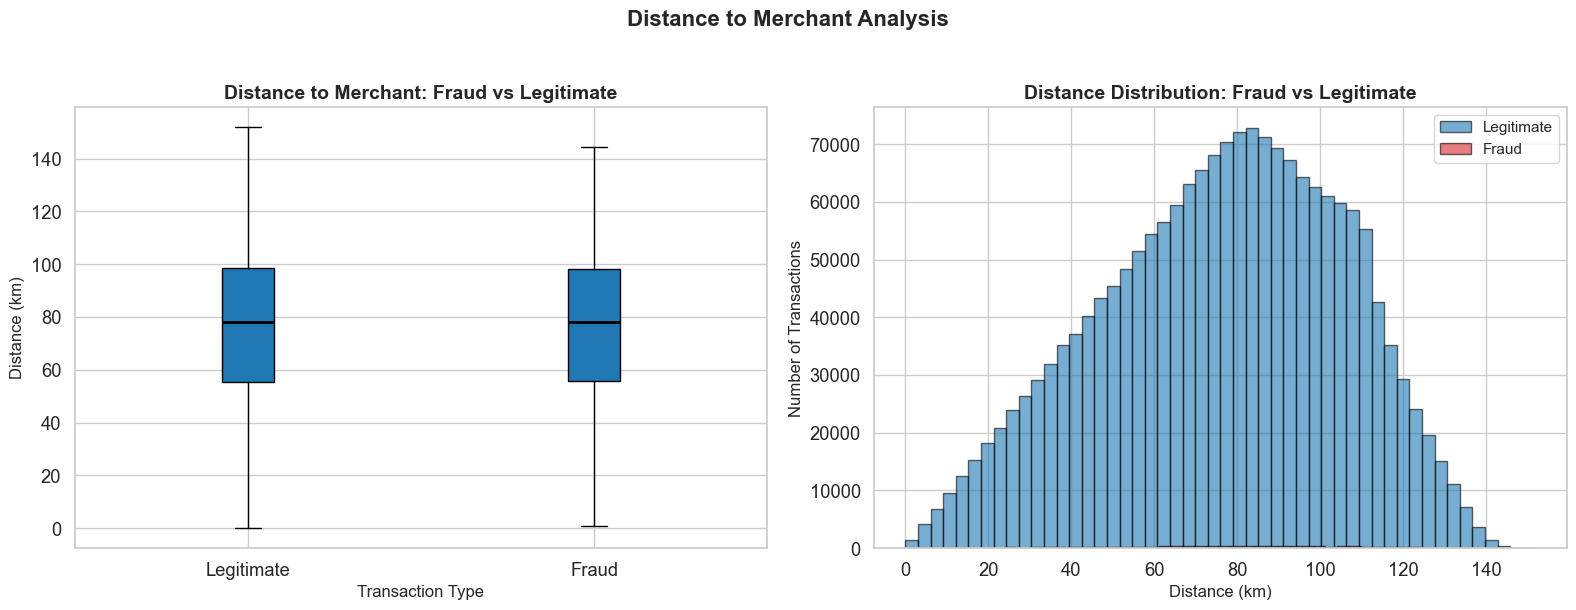

DISTANCE ANALYSIS
Metric               Legitimate           Fraud
---------------------------------------------
Mean                     76.11          76.25
Median                   78.25          78.12
Std                      29.09          28.84
Max                     151.87         144.36

Plot D3 saved successfully ✅


In [78]:
# Plot D3 — Distance Between Cardholder and Merchant
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Separate fraud and legitimate
legit_dist = df[df['is_fraud']==0]['distance_km']
fraud_dist = df[df['is_fraud']==1]['distance_km']

# Left plot — Box plot
axes[0].boxplot(
    [legit_dist, fraud_dist],
    labels=['Legitimate', 'Fraud'],
    patch_artist=True,
    boxprops=dict(facecolor=COLORS['legit']),
    medianprops=dict(color='black', linewidth=2)
)
axes[0].set_title('Distance to Merchant: Fraud vs Legitimate',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Transaction Type', fontsize=12)
axes[0].set_ylabel('Distance (km)',    fontsize=12)

# Right plot — Histogram overlay
axes[1].hist(legit_dist, bins=50, color=COLORS['legit'],
             alpha=0.6, label='Legitimate', edgecolor='black')
axes[1].hist(fraud_dist, bins=50, color=COLORS['fraud'],
             alpha=0.6, label='Fraud',      edgecolor='black')
axes[1].set_title('Distance Distribution: Fraud vs Legitimate',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Distance (km)',          fontsize=12)
axes[1].set_ylabel('Number of Transactions', fontsize=12)
axes[1].legend(fontsize=11)

plt.suptitle('Distance to Merchant Analysis',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('plots/D3_distance_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print findings
print("DISTANCE ANALYSIS")
print("=" * 50)
print(f"{'Metric':<15} {'Legitimate':>15} {'Fraud':>15}")
print("-" * 45)
print(f"{'Mean':<15} {legit_dist.mean():>14.2f} "
      f"{fraud_dist.mean():>14.2f}")
print(f"{'Median':<15} {legit_dist.median():>14.2f} "
      f"{fraud_dist.median():>14.2f}")
print(f"{'Std':<15} {legit_dist.std():>14.2f} "
      f"{fraud_dist.std():>14.2f}")
print(f"{'Max':<15} {legit_dist.max():>14.2f} "
      f"{fraud_dist.max():>14.2f}")
print()
print("Plot D3 saved successfully ✅")

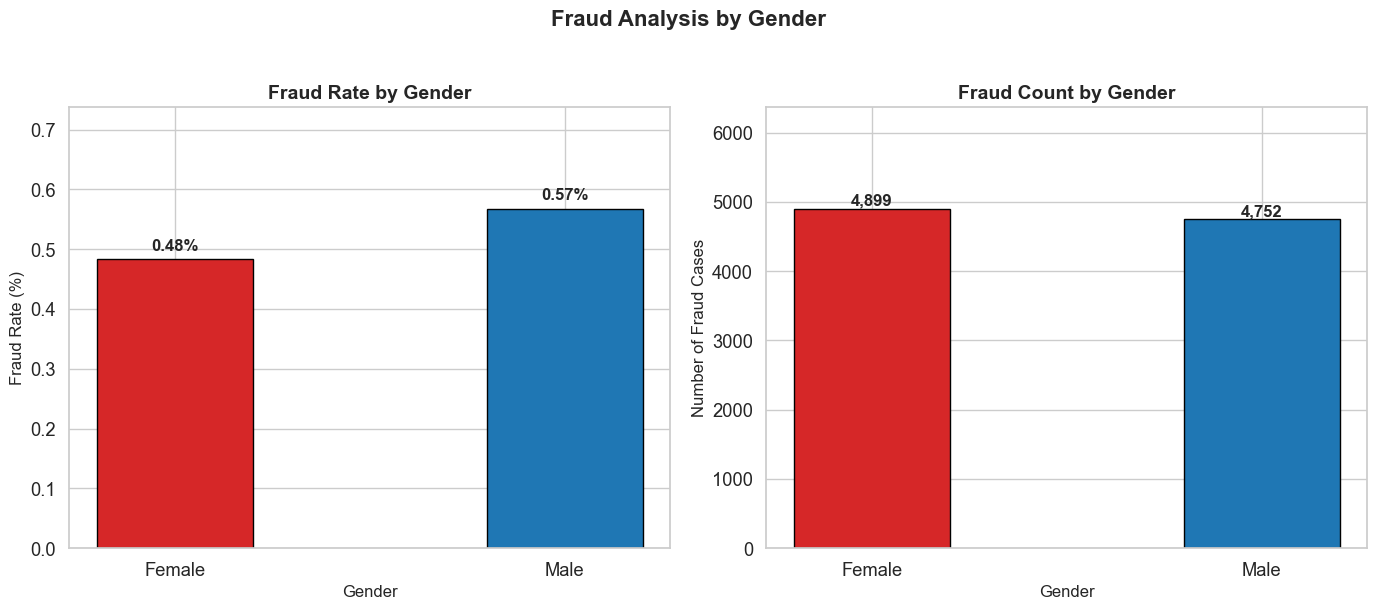

FRAUD ANALYSIS BY GENDER
Gender          Total      Fraud       Rate
----------------------------------------
Female      1,014,749      4,899       0.48%
Male          837,645      4,752       0.57%

Plot E1 saved successfully ✅


In [80]:
# Plot E1 — Fraud Rate by Gender
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Calculate fraud rate by gender
gender_fraud_rate  = df.groupby('gender')['is_fraud'].mean() * 100
gender_fraud_count = df.groupby('gender')['is_fraud'].sum()

# Left plot — Fraud Rate
bars = axes[0].bar(
    ['Female', 'Male'],
    gender_fraud_rate.values,
    color=[COLORS['fraud'], COLORS['legit']],
    edgecolor='black',
    width=0.4
)

# Add value labels
for bar, val in zip(bars, gender_fraud_rate.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.2f}%',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

axes[0].set_title('Fraud Rate by Gender',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender',         fontsize=12)
axes[0].set_ylabel('Fraud Rate (%)', fontsize=12)
axes[0].set_ylim(0, gender_fraud_rate.max() * 1.3)

# Right plot — Fraud Count
bars2 = axes[1].bar(
    ['Female', 'Male'],
    gender_fraud_count.values,
    color=[COLORS['fraud'], COLORS['legit']],
    edgecolor='black',
    width=0.4
)

# Add value labels
for bar, val in zip(bars2, gender_fraud_count.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f'{val:,}',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

axes[1].set_title('Fraud Count by Gender',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender',                  fontsize=12)
axes[1].set_ylabel('Number of Fraud Cases',   fontsize=12)
axes[1].set_ylim(0, gender_fraud_count.max() * 1.3)

plt.suptitle('Fraud Analysis by Gender',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('plots/E1_fraud_rate_by_gender.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print findings
print("FRAUD ANALYSIS BY GENDER")
print("=" * 50)
print(f"{'Gender':<10} {'Total':>10} {'Fraud':>10} {'Rate':>10}")
print("-" * 40)
for gender in ['F', 'M']:
    total = len(df[df['gender']==gender])
    fraud = df[df['gender']==gender]['is_fraud'].sum()
    rate  = fraud/total*100
    name  = 'Female' if gender=='F' else 'Male'
    print(f"{name:<10} {total:>10,} {fraud:>10,} {rate:>10.2f}%")
print()
print("Plot E1 saved successfully ✅")

In [84]:
# Check current columns
print("CURRENT COLUMNS IN DATAFRAME")
print("=" * 50)
print(df.columns.tolist())
print()
print(f"Total columns : {df.shape[1]}")
print()

# Check if age exists
if 'age' in df.columns:
    print("age column EXISTS ✅")
else:
    print("age column MISSING ❌")
    print("Recreating age column now...")
    
    # Recreate age column
    df['dob'] = pd.to_datetime(df['dob'])
    df['age'] = (pd.Timestamp.today() - df['dob']).dt.days // 365
    
    print(f"age column recreated ✅")
    print(f"Min age : {df['age'].min()}")
    print(f"Max age : {df['age'].max()}")
    print(f"Avg age : {df['age'].mean():.1f}")
    

CURRENT COLUMNS IN DATAFRAME
['trans_date_trans_time', 'merchant', 'category', 'amt', 'gender', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'trans_hour', 'trans_day', 'trans_month', 'trans_year', 'trans_weekday', 'is_high_amount', 'distance_km', 'amt_bin', 'trans_date']

Total columns : 27

age column MISSING ❌
Recreating age column now...
age column recreated ✅
Min age : 21
Max age : 101
Avg age : 52.2


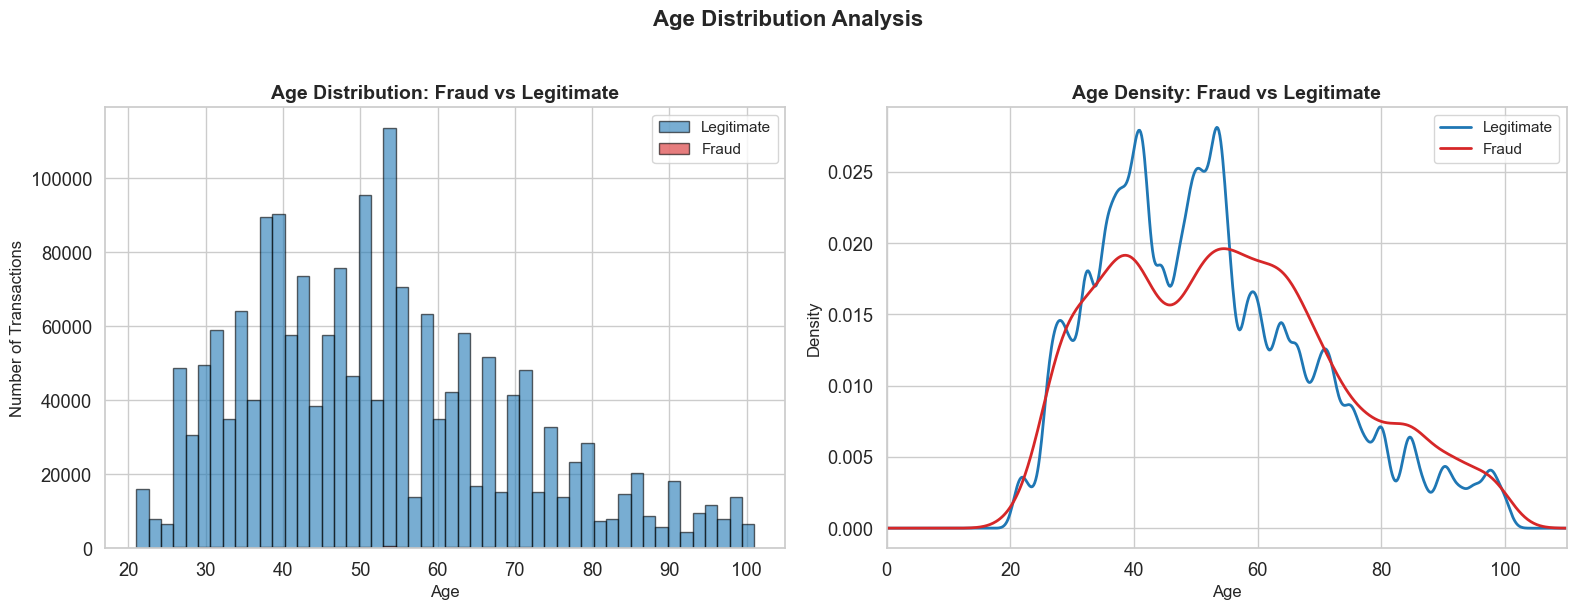

AGE STATISTICS
Metric               Legitimate           Fraud
---------------------------------------------
Mean                       52.2            54.9
Median                     50.0            54.0
Std                        17.4            18.6
Min                        21.0            21.0
Max                       101.0           101.0

Plot E2 saved successfully ✅


In [87]:
# Plot E2 — Age Distribution Fraud vs Legitimate
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Separate fraud and legitimate
legit_age = df[df['is_fraud']==0]['age']
fraud_age  = df[df['is_fraud']==1]['age']

# Left plot — Overlapping Histogram
axes[0].hist(legit_age, bins=50, color=COLORS['legit'],
             alpha=0.6, label='Legitimate', edgecolor='black')
axes[0].hist(fraud_age, bins=50, color=COLORS['fraud'],
             alpha=0.6, label='Fraud',      edgecolor='black')
axes[0].set_title('Age Distribution: Fraud vs Legitimate',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age',                    fontsize=12)
axes[0].set_ylabel('Number of Transactions', fontsize=12)
axes[0].legend(fontsize=11)

# Right plot — KDE plot
legit_age.plot.kde(ax=axes[1], color=COLORS['legit'],
                   linewidth=2, label='Legitimate')
fraud_age.plot.kde(ax=axes[1], color=COLORS['fraud'],
                   linewidth=2, label='Fraud')
axes[1].set_title('Age Density: Fraud vs Legitimate',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age',        fontsize=12)
axes[1].set_ylabel('Density',    fontsize=12)
axes[1].legend(fontsize=11)
axes[1].set_xlim(0, 110)

plt.suptitle('Age Distribution Analysis',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('plots/E2_age_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print findings
print("AGE STATISTICS")
print("=" * 50)
print(f"{'Metric':<15} {'Legitimate':>15} {'Fraud':>15}")
print("-" * 45)
print(f"{'Mean':<15} {legit_age.mean():>15.1f} "
      f"{fraud_age.mean():>15.1f}")
print(f"{'Median':<15} {legit_age.median():>15.1f} "
      f"{fraud_age.median():>15.1f}")
print(f"{'Std':<15} {legit_age.std():>15.1f} "
      f"{fraud_age.std():>15.1f}")
print(f"{'Min':<15} {legit_age.min():>15.1f} "
      f"{fraud_age.min():>15.1f}")
print(f"{'Max':<15} {legit_age.max():>15.1f} "
      f"{fraud_age.max():>15.1f}")
print()
print("Plot E2 saved successfully ✅")

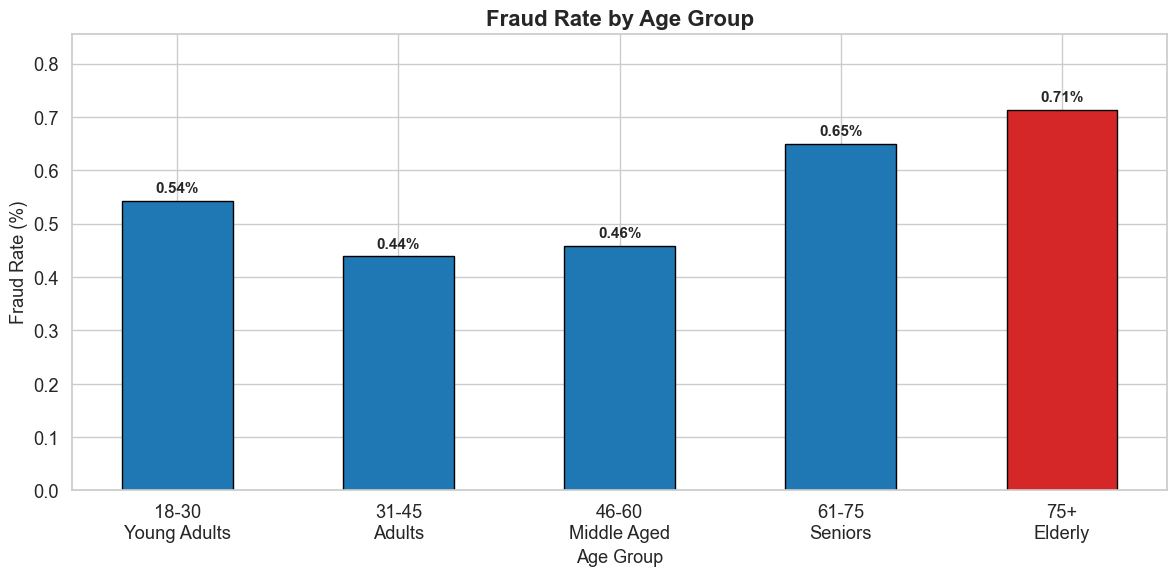

FRAUD RATE BY AGE GROUP
  18-30
Young Adults        : 0.54% ██████████
  31-45
Adults              : 0.44% ████████
  46-60
Middle Aged         : 0.46% █████████
  61-75
Seniors             : 0.65% █████████████
  75+
Elderly               : 0.71% ██████████████

Most targeted age group : 75+
Elderly
Highest fraud rate      : 0.71%
Safest age group        : 31-45
Adults
Lowest fraud rate       : 0.44%
Plot E3 saved successfully ✅


In [89]:
# Plot E3 — Fraud Rate by Age Group
fig, ax = plt.subplots(figsize=(12, 6))

# Create age bins
age_bins   = [0, 30, 45, 60, 75, 120]
age_labels = ['18-30\nYoung Adults',
              '31-45\nAdults',
              '46-60\nMiddle Aged',
              '61-75\nSeniors',
              '75+\nElderly']

# Create age group column
df['age_group'] = pd.cut(df['age'],
                          bins=age_bins,
                          labels=age_labels)

# Calculate fraud rate per age group
age_fraud_rate = df.groupby('age_group',
                             observed=True)['is_fraud'].mean() * 100

# Define colors — highlight peak age group in red
colors = [COLORS['fraud'] if rate == age_fraud_rate.max()
          else COLORS['legit']
          for rate in age_fraud_rate.values]

# Plot bars
bars = ax.bar(
    age_fraud_rate.index,
    age_fraud_rate.values,
    color=colors,
    edgecolor='black',
    width=0.5
)

# Add value labels on bars
for bar, val in zip(bars, age_fraud_rate.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.2f}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

# Labels and title
ax.set_title('Fraud Rate by Age Group',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Age Group',      fontsize=13)
ax.set_ylabel('Fraud Rate (%)', fontsize=13)
ax.set_ylim(0, age_fraud_rate.max() * 1.2)

plt.tight_layout()
plt.savefig('plots/E3_fraud_rate_by_age_group.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print findings
print("FRAUD RATE BY AGE GROUP")
print("=" * 50)
for group, rate in age_fraud_rate.items():
    bar = '█' * int(rate * 20)
    print(f"  {group:<25} : {rate:.2f}% {bar}")
print()
print(f"Most targeted age group : {age_fraud_rate.idxmax()}")
print(f"Highest fraud rate      : {age_fraud_rate.max():.2f}%")
print(f"Safest age group        : {age_fraud_rate.idxmin()}")
print(f"Lowest fraud rate       : {age_fraud_rate.min():.2f}%")
print("Plot E3 saved successfully ✅")

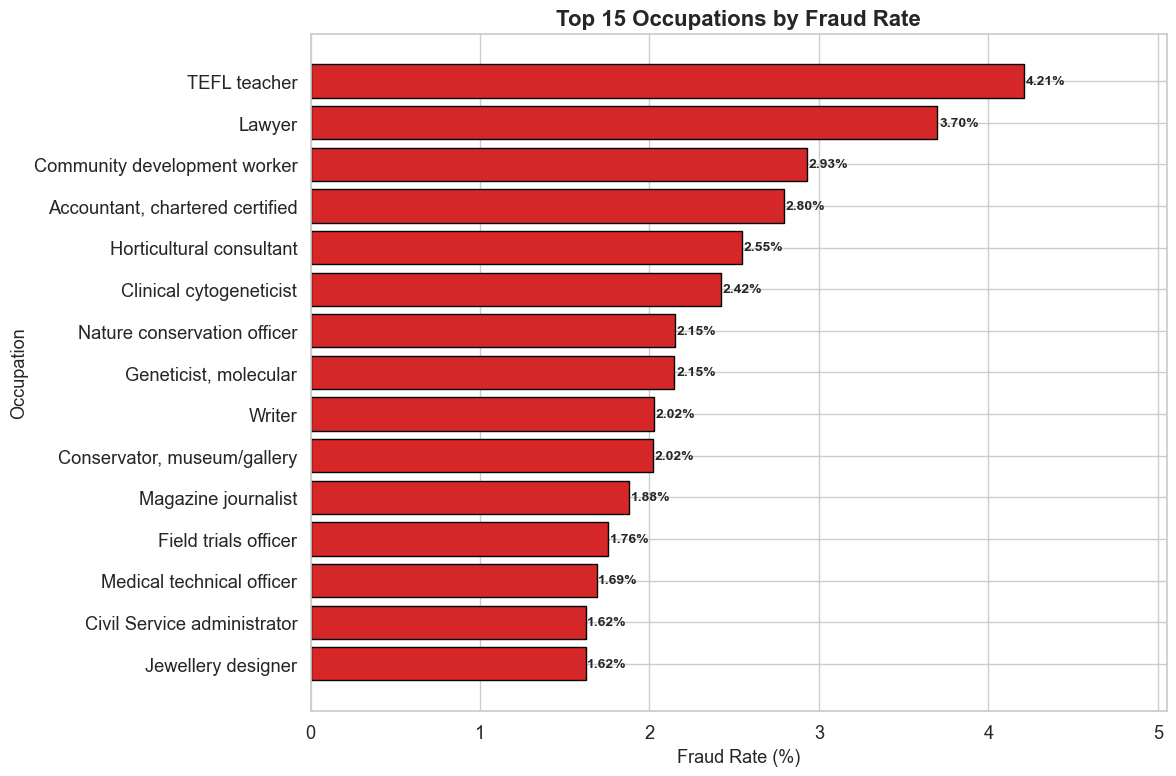

TOP 15 OCCUPATIONS BY FRAUD RATE
  TEFL teacher                             : 4.21% ████████████████████████████████████████████████████████████████████████████████████
  Lawyer                                   : 3.70% █████████████████████████████████████████████████████████████████████████
  Community development worker             : 2.93% ██████████████████████████████████████████████████████████
  Accountant, chartered certified          : 2.80% ███████████████████████████████████████████████████████
  Horticultural consultant                 : 2.55% ██████████████████████████████████████████████████
  Clinical cytogeneticist                  : 2.42% ████████████████████████████████████████████████
  Nature conservation officer              : 2.15% ███████████████████████████████████████████
  Geneticist, molecular                    : 2.15% ██████████████████████████████████████████
  Writer                                   : 2.02% ████████████████████████████████████████
  Cons

In [91]:
# Plot E4 — Top 15 Jobs with Highest Fraud Rate
fig, ax = plt.subplots(figsize=(12, 8))

# Calculate fraud rate per job
# Only include jobs with at least 100 transactions
job_counts     = df.groupby('job').size()
valid_jobs     = job_counts[job_counts >= 100].index
job_fraud_rate = df[df['job'].isin(valid_jobs)]\
                 .groupby('job')['is_fraud'].mean() * 100
job_fraud_rate = job_fraud_rate.sort_values(ascending=True).tail(15)

# Plot horizontal bar chart
bars = ax.barh(
    job_fraud_rate.index,
    job_fraud_rate.values,
    color=COLORS['fraud'],
    edgecolor='black'
)

# Add value labels on bars
for bar, val in zip(bars, job_fraud_rate.values):
    ax.text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}%',
        ha='left', va='center',
        fontsize=10, fontweight='bold'
    )

# Labels and title
ax.set_title('Top 15 Occupations by Fraud Rate',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Fraud Rate (%)', fontsize=13)
ax.set_ylabel('Occupation',     fontsize=13)
ax.set_xlim(0, job_fraud_rate.max() * 1.2)

plt.tight_layout()
plt.savefig('plots/E4_fraud_rate_by_job.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print findings
print("TOP 15 OCCUPATIONS BY FRAUD RATE")
print("=" * 50)
for job, rate in job_fraud_rate.sort_values(ascending=False).items():
    bar = '█' * int(rate * 20)
    print(f"  {job:<40} : {rate:.2f}% {bar}")
print()
print(f"Most targeted job : {job_fraud_rate.idxmax()}")
print(f"Highest fraud rate: {job_fraud_rate.max():.2f}%")
print("Plot E4 saved successfully ✅")

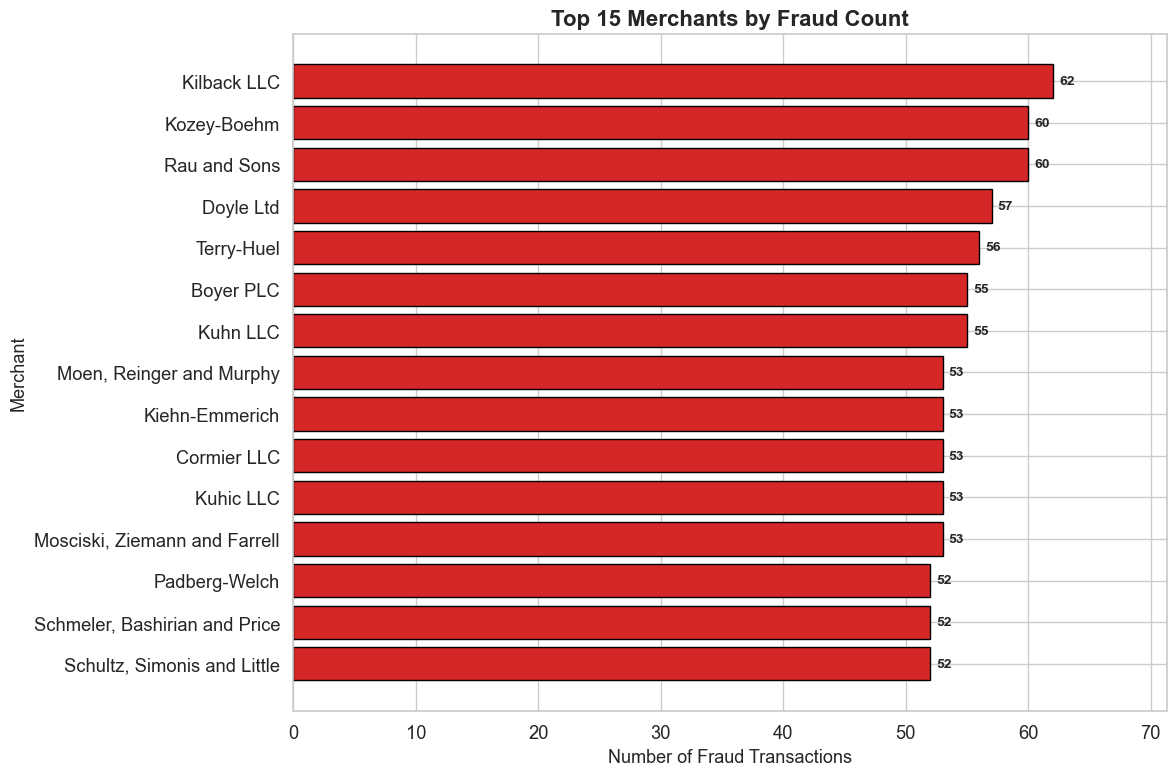

TOP 15 MERCHANTS BY FRAUD COUNT
  Kilback LLC                         : 62 ███████████████████████████████
  Rau and Sons                        : 60 ██████████████████████████████
  Kozey-Boehm                         : 60 ██████████████████████████████
  Doyle Ltd                           : 57 ████████████████████████████
  Terry-Huel                          : 56 ████████████████████████████
  Kuhn LLC                            : 55 ███████████████████████████
  Boyer PLC                           : 55 ███████████████████████████
  Mosciski, Ziemann and Farrell       : 53 ██████████████████████████
  Kuhic LLC                           : 53 ██████████████████████████
  Cormier LLC                         : 53 ██████████████████████████
  Kiehn-Emmerich                      : 53 ██████████████████████████
  Moen, Reinger and Murphy            : 53 ██████████████████████████
  Schultz, Simonis and Little         : 52 ██████████████████████████
  Schmeler, Bashirian and Price       :

In [93]:
# Plot F1 — Top 15 Merchants by Fraud Count
fig, ax = plt.subplots(figsize=(12, 8))

# Calculate fraud count per merchant
merchant_fraud_count = df[df['is_fraud']==1]\
                       .groupby('merchant').size()
merchant_fraud_count = merchant_fraud_count\
                       .sort_values(ascending=True).tail(15)

# Plot horizontal bar chart
bars = ax.barh(
    merchant_fraud_count.index,
    merchant_fraud_count.values,
    color=COLORS['fraud'],
    edgecolor='black'
)

# Add value labels on bars
for bar, val in zip(bars, merchant_fraud_count.values):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{val:,}',
        ha='left', va='center',
        fontsize=10, fontweight='bold'
    )

# Labels and title
ax.set_title('Top 15 Merchants by Fraud Count',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Number of Fraud Transactions', fontsize=13)
ax.set_ylabel('Merchant',                     fontsize=13)
ax.set_xlim(0, merchant_fraud_count.max() * 1.15)

plt.tight_layout()
plt.savefig('plots/F1_top_merchants_fraud_count.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print findings
print("TOP 15 MERCHANTS BY FRAUD COUNT")
print("=" * 50)
for merchant, count in merchant_fraud_count\
                        .sort_values(ascending=False).items():
    bar = '█' * int(count / 2)
    print(f"  {merchant:<35} : {count:,} {bar}")
print()
print(f"Most frauded merchant : {merchant_fraud_count.idxmax()}")
print(f"Fraud count           : {merchant_fraud_count.max():,}")
print("Plot F1 saved successfully ✅")

In [95]:
from scipy import stats

print("MANN-WHITNEY U TEST RESULTS")
print("=" * 60)
print("Testing if fraud and legitimate transactions differ")
print("significantly in key numeric features")
print("=" * 60)
print()

# Features to test
features = ['amt', 'age', 'city_pop', 'distance_km']

for feature in features:
    # Separate fraud and legitimate
    legit = df[df['is_fraud']==0][feature].dropna()
    fraud = df[df['is_fraud']==1][feature].dropna()
    
    # Run Mann-Whitney U test
    stat, p = stats.mannwhitneyu(legit, fraud,
                                  alternative='two-sided')
    
    print(f"FEATURE : {feature}")
    print(f"  Legit mean  : {legit.mean():.4f}")
    print(f"  Fraud mean  : {fraud.mean():.4f}")
    print(f"  U statistic : {stat:.2f}")
    print(f"  P value     : {p:.6f}")
    
    if p < 0.05:
        print(f"  Result      : ✅ SIGNIFICANT difference found")
        print(f"  Meaning     : {feature} is useful for fraud detection")
    else:
        print(f"  Result      : ❌ No significant difference found")
        print(f"  Meaning     : {feature} may not help detect fraud")
    print()

print("=" * 60)
print("Significance level : 0.05")
print("If p < 0.05 → difference is statistically significant")

MANN-WHITNEY U TEST RESULTS
Testing if fraud and legitimate transactions differ
significantly in key numeric features

FEATURE : amt
  Legit mean  : 67.6513
  Fraud mean  : 530.6614
  U statistic : 2947164898.00
  P value     : 0.000000
  Result      : ✅ SIGNIFICANT difference found
  Meaning     : amt is useful for fraud detection

FEATURE : age
  Legit mean  : 52.2308
  Fraud mean  : 54.9379
  U statistic : 8141237850.00
  P value     : 0.000000
  Result      : ✅ SIGNIFICANT difference found
  Meaning     : age is useful for fraud detection

FEATURE : city_pop
  Legit mean  : 88636.5793
  Fraud mean  : 89998.4230
  U statistic : 8751745957.00
  P value     : 0.007366
  Result      : ✅ SIGNIFICANT difference found
  Meaning     : city_pop is useful for fraud detection

FEATURE : distance_km
  Legit mean  : 76.1088
  Fraud mean  : 76.2549
  U statistic : 8877699246.00
  P value     : 0.782608
  Result      : ❌ No significant difference found
  Meaning     : distance_km may not help det

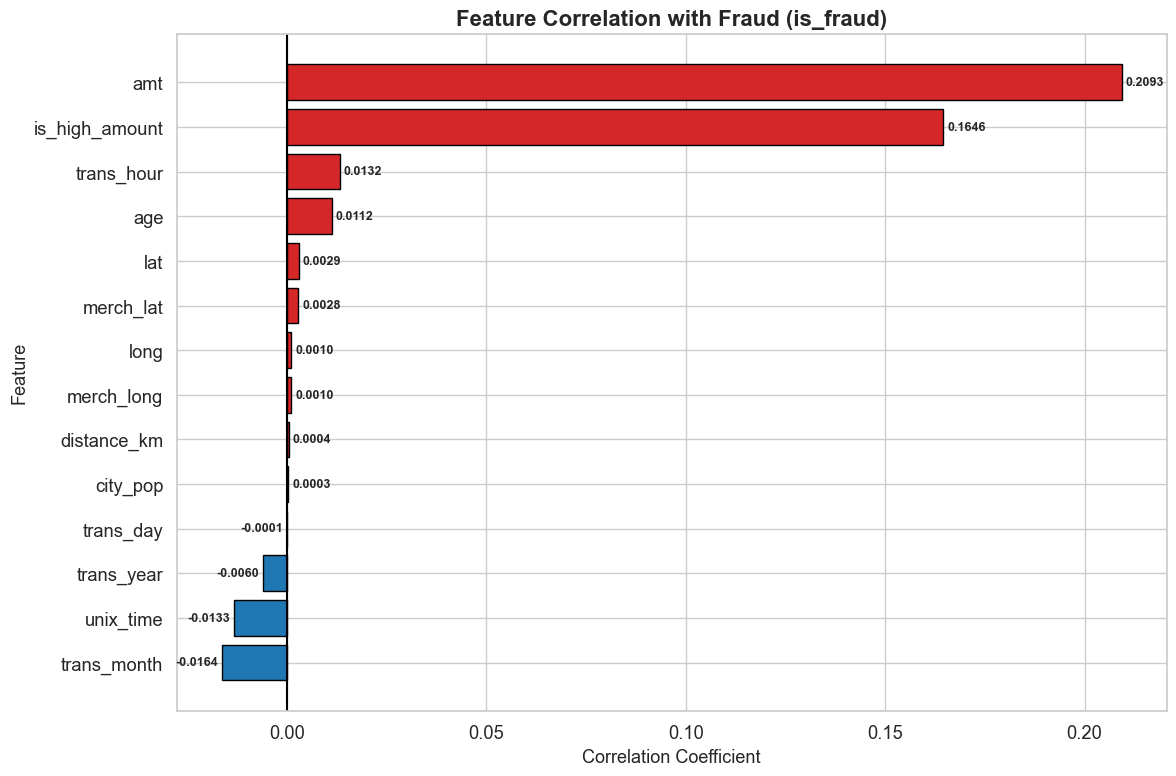

FEATURE CORRELATION WITH FRAUD
  amt                  :   0.2093  ↑ positive
  is_high_amount       :   0.1646  ↑ positive
  trans_hour           :   0.0132  ↑ positive
  age                  :   0.0112  ↑ positive
  lat                  :   0.0029  ↑ positive
  merch_lat            :   0.0028  ↑ positive
  long                 :   0.0010  ↑ positive
  merch_long           :   0.0010  ↑ positive
  distance_km          :   0.0004  ↑ positive
  city_pop             :   0.0003  ↑ positive
  trans_day            :  -0.0001  ↓ negative
  trans_year           :  -0.0060  ↓ negative
  unix_time            :  -0.0133  ↓ negative
  trans_month          :  -0.0164  ↓ negative

Strongest positive correlation : amt (0.2093)
Strongest negative correlation : trans_month (-0.0164)
Plot G2 saved successfully ✅


In [97]:
# Plot G2 — Feature Correlation with Fraud
fig, ax = plt.subplots(figsize=(12, 8))

# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove target variable from features
numeric_cols = [col for col in numeric_cols if col != 'is_fraud']

# Calculate correlation with is_fraud
correlations = df[numeric_cols].corrwith(df['is_fraud'])
correlations = correlations.sort_values(ascending=True)

# Define colors based on correlation direction
colors = [COLORS['fraud'] if val > 0
          else COLORS['legit']
          for val in correlations.values]

# Plot horizontal bar chart
bars = ax.barh(
    correlations.index,
    correlations.values,
    color=colors,
    edgecolor='black'
)

# Add value labels on bars
for bar, val in zip(bars, correlations.values):
    ax.text(
        bar.get_width() + 0.001 if val >= 0
        else bar.get_width() - 0.001,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        ha='left' if val >= 0 else 'right',
        va='center',
        fontsize=9, fontweight='bold'
    )

# Add vertical line at 0
ax.axvline(x=0, color='black', linewidth=1.5)

# Labels and title
ax.set_title('Feature Correlation with Fraud (is_fraud)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Correlation Coefficient', fontsize=13)
ax.set_ylabel('Feature',                 fontsize=13)

plt.tight_layout()
plt.savefig('plots/G2_feature_correlation.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print findings
print("FEATURE CORRELATION WITH FRAUD")
print("=" * 50)
correlations_desc = correlations.sort_values(ascending=False)
for feature, corr in correlations_desc.items():
    direction = '↑ positive' if corr > 0 else '↓ negative'
    print(f"  {feature:<20} : {corr:>8.4f}  {direction}")
print()
print(f"Strongest positive correlation : "
      f"{correlations_desc.index[0]} "
      f"({correlations_desc.iloc[0]:.4f})")
print(f"Strongest negative correlation : "
      f"{correlations_desc.index[-1]} "
      f"({correlations_desc.iloc[-1]:.4f})")
print("Plot G2 saved successfully ✅")

In [99]:
print("EFFECT SIZE ANALYSIS - COHEN'S D")
print("=" * 60)
print()
print("Interpretation:")
print("  Small  effect : d = 0.2")
print("  Medium effect : d = 0.5")
print("  Large  effect : d = 0.8+")
print("=" * 60)
print()

def cohens_d(group1, group2):
    """Calculate Cohen's d effect size"""
    n1, n2   = len(group1), len(group2)
    mean1    = group1.mean()
    mean2    = group2.mean()
    std1     = group1.std()
    std2     = group2.std()
    
    # Pooled standard deviation
    pooled_std = np.sqrt(
        ((n1 - 1) * std1**2 + (n2 - 1) * std2**2) /
        (n1 + n2 - 2)
    )
    
    # Cohen's d
    d = abs(mean1 - mean2) / pooled_std
    return d

# Features to analyze
features = ['amt', 'age', 'city_pop', 'distance_km']

for feature in features:
    legit = df[df['is_fraud']==0][feature].dropna()
    fraud = df[df['is_fraud']==1][feature].dropna()
    
    d = cohens_d(legit, fraud)
    
    # Interpret effect size
    if d >= 0.8:
        interpretation = 'LARGE effect'
        symbol = '🔴'
    elif d >= 0.5:
        interpretation = 'MEDIUM effect'
        symbol = '🟡'
    elif d >= 0.2:
        interpretation = 'SMALL effect'
        symbol = '🟢'
    else:
        interpretation = 'NEGLIGIBLE effect'
        symbol = '⚪'
    
    print(f"FEATURE  : {feature}")
    print(f"  Legit mean : {legit.mean():.4f}")
    print(f"  Fraud mean : {fraud.mean():.4f}")
    print(f"  Cohen's d  : {d:.4f}")
    print(f"  Effect     : {symbol} {interpretation}")
    print()

print("=" * 60)
print("Features with LARGE effect are most valuable")
print("for fraud detection modeling in Phase 3")

EFFECT SIZE ANALYSIS - COHEN'S D

Interpretation:
  Small  effect : d = 0.2
  Medium effect : d = 0.5
  Large  effect : d = 0.8+

FEATURE  : amt
  Legit mean : 67.6513
  Fraud mean : 530.6614
  Cohen's d  : 2.9732
  Effect     : 🔴 LARGE effect

FEATURE  : age
  Legit mean : 52.2308
  Fraud mean : 54.9379
  Cohen's d  : 0.1554
  Effect     : ⚪ NEGLIGIBLE effect

FEATURE  : city_pop
  Legit mean : 88636.5793
  Fraud mean : 89998.4230
  Cohen's d  : 0.0045
  Effect     : ⚪ NEGLIGIBLE effect

FEATURE  : distance_km
  Legit mean : 76.1088
  Fraud mean : 76.2549
  Cohen's d  : 0.0050
  Effect     : ⚪ NEGLIGIBLE effect

Features with LARGE effect are most valuable
for fraud detection modeling in Phase 3


In [101]:
print("=" * 60)
print("KEY FINDINGS SUMMARY")
print("Phase 1 - Credit Card Fraud Detection EDA")
print("=" * 60)

print("""
FINDING 1 → CLASS IMBALANCE
─────────────────────────────────────────────────────────
Only 0.52% of transactions are fraudulent
→ 1,842,743 legitimate transactions
→     9,651 fraud transactions
→ For every 1 fraud there are 190 legitimate
→ Severe imbalance needs special handling in Phase 3
→ Techniques like SMOTE or class weights will be needed

FINDING 2 → TRANSACTION AMOUNT IS KEY SIGNAL
─────────────────────────────────────────────────────────
Fraud transactions are 8.2x larger than legitimate
→ Fraud median    : $390.00
→ Legit median    : $47.24
→ Cohen's d       : 2.97 (extremely large effect)
→ Correlation     : 0.2093 (strongest feature)
→ amt is the single most powerful fraud detection feature

FINDING 3 → HIGH AMOUNT TRANSACTIONS ARE VERY RISKY
─────────────────────────────────────────────────────────
Transactions above $1000 have 22.20% fraud rate
→ Overall fraud rate    : 0.52%
→ Above $1000 fraud rate: 22.20%
→ High amount transactions are 43x more likely to be fraud
→ $500-$1000 range also very risky at 21.37%

FINDING 4 → MERCHANT CATEGORY PATTERNS
─────────────────────────────────────────────────────────
Top 3 highest fraud rate categories:
→ shopping_net  : 1.59% (online shopping)
→ misc_net      : 1.30% (online misc)
→ grocery_pos   : 1.26% (physical grocery)
Online categories are 2.5x riskier than physical stores
grocery_pos has highest absolute fraud count at 2,228 cases

FINDING 5 → PEAK FRAUD TIME WINDOW
─────────────────────────────────────────────────────────
Most dangerous fraud window is Thursday at 10 PM
→ Peak fraud hour    : 10 PM - 11 PM
→ Peak fraud day     : Wednesday to Friday
→ Peak fraud window  : Thursday 10 PM = 3.27% fraud rate
→ This is 6.3x higher than average fraud rate
→ Daytime hours (6AM-9PM) have very low fraud ~0.10%

FINDING 6 → SEASONAL PATTERNS
─────────────────────────────────────────────────────────
February has highest fraud rate at 0.87%
→ High fraud period   : January and February
→ Low fraud period    : December (0.30%)
→ Opposite of expected holiday season pattern
→ Banks increase monitoring in Dec reducing fraud

FINDING 7 → GEOGRAPHIC PATTERNS
─────────────────────────────────────────────────────────
New York has highest fraud COUNT with 730 cases
Rhode Island has highest fraud RATE at 2.01%
→ Small states have higher rates
→ Large states have higher counts
→ Delaware anomaly found and fixed (only 9 transactions)
→ Distance to merchant is NOT a fraud signal (d=0.005)

FINDING 8 → DEMOGRAPHIC PATTERNS
─────────────────────────────────────────────────────────
Two most vulnerable groups identified:
→ Elderly (75+)      : 0.71% fraud rate (highest)
→ Young Adults (18-30): 0.54% fraud rate
→ Adults (31-45)     : 0.44% fraud rate (safest)
→ Males targeted more than females (0.57% vs 0.48%)
→ Fraud victims are on average 2.7 years older

FINDING 9 → OCCUPATION PATTERNS
─────────────────────────────────────────────────────────
TEFL teachers have highest fraud rate at 4.21%
→ 8.1x higher than overall average of 0.52%
→ Mix of high and low income jobs in top 15
→ Lawyers at 3.70% and Accountants at 2.80%
→ Job type alone does not explain fraud targeting

FINDING 10 → STATISTICAL SIGNIFICANCE
─────────────────────────────────────────────────────────
Mann-Whitney U tests confirm:
→ amt         : p=0.000000 ✅ SIGNIFICANT (d=2.97 LARGE)
→ age         : p=0.000000 ✅ SIGNIFICANT (d=0.15 NEGLIGIBLE)
→ city_pop    : p=0.007366 ✅ SIGNIFICANT (d=0.00 NEGLIGIBLE)
→ distance_km : p=0.782608 ❌ NOT SIGNIFICANT
→ Statistical significance ≠ practical importance
→ Always check both p-value AND effect size

FINDING 11 → DATA QUALITY ISSUES RESOLVED
─────────────────────────────────────────────────────────
9 data quality issues found and fixed:
→ Dropped 5 useless/PII columns
→ Fixed datetime format
→ Calculated age from dob
→ Removed fraud_ prefix from merchants
→ Converted zip to string
→ No duplicates found
→ Flagged high amount outliers
→ Fixed Delaware sampling artifact
→ Standardized categorical columns

FINDING 12 → PHASE 2 FEATURE RECOMMENDATIONS
─────────────────────────────────────────────────────────
Key features for Phase 2 engineering:
→ amt            : strongest signal (keep as is)
→ is_high_amount : engineered flag (very useful)
→ trans_hour     : time based feature (important)
→ trans_weekday  : day based feature (useful)
→ age_group      : demographic feature (useful)
→ category       : merchant category (useful)
→ amt_bin        : amount range feature (useful)
→ distance_km    : weak signal (optional)
""")

print("=" * 60)
print("Total Findings Documented : 12")
print("Total Plots Created       : 20+")
print("Total Rows Analyzed       : 1,852,394")
print("Phase 1 EDA Complete      : ✅")
print("=" * 60)

KEY FINDINGS SUMMARY
Phase 1 - Credit Card Fraud Detection EDA

FINDING 1 → CLASS IMBALANCE
─────────────────────────────────────────────────────────
Only 0.52% of transactions are fraudulent
→ 1,842,743 legitimate transactions
→     9,651 fraud transactions
→ For every 1 fraud there are 190 legitimate
→ Severe imbalance needs special handling in Phase 3
→ Techniques like SMOTE or class weights will be needed

FINDING 2 → TRANSACTION AMOUNT IS KEY SIGNAL
─────────────────────────────────────────────────────────
Fraud transactions are 8.2x larger than legitimate
→ Fraud median    : $390.00
→ Legit median    : $47.24
→ Cohen's d       : 2.97 (extremely large effect)
→ Correlation     : 0.2093 (strongest feature)
→ amt is the single most powerful fraud detection feature

FINDING 3 → HIGH AMOUNT TRANSACTIONS ARE VERY RISKY
─────────────────────────────────────────────────────────
Transactions above $1000 have 22.20% fraud rate
→ Overall fraud rate    : 0.52%
→ Above $1000 fraud rate: 22.20

In [105]:
# Save Data Quality Report
report = """
================================================================
DATA QUALITY REPORT
Project  : Credit Card Fraud Detection
Phase    : 1 - Data Cleaning & EDA
Dataset  : Sparkov Credit Card Transactions
Author   : [Your Name]
Date     : 2024
================================================================

DATASET OVERVIEW
----------------------------------------------------------------
Source          : Kaggle - kartik2112
Files           : fraudTrain.csv + fraudTest.csv
Total Rows      : 1,852,394
Total Columns   : 23 (original) → 26 (after feature engineering)
Target Variable : is_fraud (0=legitimate, 1=fraud)
Fraud Rate      : 0.52%
Dataset Type    : Synthetic (Sparkov Data Generation)

================================================================
ISSUES FOUND & DECISIONS MADE
================================================================

ISSUE 1 → Unnamed: 0 Column
----------------------------------------------------------------
Problem  : Redundant row index column
Action   : DROPPED
Rationale: pandas already has its own index
           This column adds zero information
           to analysis or modeling

ISSUE 2 → trans_date_trans_time Column
----------------------------------------------------------------
Problem  : Stored as object/string instead of datetime
Action   : CONVERTED to datetime64[ns]
           EXTRACTED 5 new features:
           → trans_hour    (0-23)
           → trans_day     (1-31)
           → trans_month   (1-12)
           → trans_year    (2019/2020)
           → trans_weekday (Monday-Sunday)
Rationale: Time based features are critical
           for fraud pattern detection

ISSUE 3 → dob Column
----------------------------------------------------------------
Problem  : Date of birth stored as string
Action   : CONVERTED to datetime
           CALCULATED age from dob
Rationale: Raw dob is not useful
           Age is a meaningful numeric feature
           for demographic fraud analysis

ISSUE 4 → merchant Column
----------------------------------------------------------------
Problem  : All merchant names had fraud_ prefix
           Example: fraud_Rippin, Kub and Mann
Action   : REMOVED fraud_ prefix using str.replace()
Rationale: The prefix is a data generation artifact
           not a real merchant name characteristic

ISSUE 5 → zip Column
----------------------------------------------------------------
Problem  : Stored as int64 instead of string
Action   : CONVERTED to string using astype(str)
Rationale: Zip codes are identifiers not numbers
           Mathematical operations on zip codes
           are meaningless

ISSUE 6 → amt Column (Outliers)
----------------------------------------------------------------
Problem  : Extreme values up to $28,948.90
Action   : KEPT outliers intentionally
           FLAGGED with is_high_amount column
           (1 if amt > $1000 else 0)
Rationale: High amounts are fraud signals
           Removing them would lose valuable
           fraud detection information
           Fraud rate above $1000 is 22.20%

ISSUE 7 → PII Columns
----------------------------------------------------------------
Problem  : cc_num, first, last, street contain
           sensitive personal information
Action   : DROPPED all 4 columns
Rationale: Privacy protection
           These features cannot generalize
           in fraud detection modeling

ISSUE 8 → Duplicate Transactions
----------------------------------------------------------------
Problem  : Possible duplicate trans_num values
Action   : CHECKED for duplicates
Result   : 0 duplicates found
           No action needed

ISSUE 9 → Delaware State Anomaly
----------------------------------------------------------------
Problem  : Delaware showed 100% fraud rate
Action   : INVESTIGATED → found only 9 transactions
           FILTERED states with minimum 100
           transactions for rate analysis
Rationale: Small sample sizes produce
           misleading fraud rates
           Statistical reliability requires
           minimum sample size

ISSUE 10 → Missing Values
----------------------------------------------------------------
Problem  : Checked all columns for missing values
Action   : No missing values found
Rationale: Dataset is synthetically generated
           All fields were programmatically filled

================================================================
NEW FEATURES CREATED
================================================================

FEATURE 1 → trans_hour
Source    : trans_date_trans_time
Type      : Integer (0-23)
Purpose   : Time based fraud pattern detection

FEATURE 2 → trans_day
Source    : trans_date_trans_time
Type      : Integer (1-31)
Purpose   : Day based fraud pattern analysis

FEATURE 3 → trans_month
Source    : trans_date_trans_time
Type      : Integer (1-12)
Purpose   : Seasonal fraud pattern detection

FEATURE 4 → trans_year
Source    : trans_date_trans_time
Type      : Integer (2019/2020)
Purpose   : Year based trend analysis

FEATURE 5 → trans_weekday
Source    : trans_date_trans_time
Type      : String (Monday-Sunday)
Purpose   : Day of week fraud pattern analysis

FEATURE 6 → age
Source    : dob
Type      : Integer
Purpose   : Demographic fraud analysis
            Older cardholders more targeted

FEATURE 7 → distance_km
Source    : lat, long, merch_lat, merch_long
Type      : Float
Purpose   : Geographic fraud signal
            Note: Found to be weak signal (d=0.005)

FEATURE 8 → is_high_amount
Source    : amt
Type      : Binary (0/1)
Purpose   : Flag transactions above $1000
            22.20% fraud rate for flagged transactions

================================================================
FINAL DATASET STATISTICS
================================================================

Total Rows              : 1,852,394
Total Columns           : 26
Legitimate Transactions : 1,842,743 (99.48%)
Fraud Transactions      :     9,651  (0.52%)
Missing Values          : 0
Duplicate Transactions  : 0
Amount Range            : $1.00 to $28,948.90
Age Range               : 21 to 101 years
Date Range              : Jan 2019 to Dec 2020
States Covered          : 51
Unique Categories       : 14
Unique Merchants        : 693

================================================================
OUTPUT FILES
================================================================

creditcard_clean.csv     → Cleaned dataset ready for Phase 2
plots/A1_*.png           → Class distribution plot
plots/A2_*.png           → Fraud pie chart
plots/A3_*.png           → Fraud rate by category
plots/A4_*.png           → Transaction volume by category
plots/B1_*.png           → Amount distribution
plots/B2_*.png           → Amount boxplot
plots/B3_*.png           → Fraud rate by amount range
plots/C1_*.png           → Transaction volume over time
plots/C2_*.png           → Fraud rate by hour
plots/C3_*.png           → Fraud rate by day
plots/C4_*.png           → Fraud rate by month
plots/C5_*.png           → Fraud heatmap hour vs day
plots/D1_*.png           → Top states by fraud count
plots/D2_*.png           → Fraud rate by state
plots/D3_*.png           → Distance analysis
plots/E1_*.png           → Fraud rate by gender
plots/E2_*.png           → Age distribution
plots/E3_*.png           → Fraud rate by age group
plots/E4_*.png           → Fraud rate by occupation
plots/F1_*.png           → Top merchants by fraud count
plots/G2_*.png           → Feature correlation with fraud

================================================================
RECOMMENDATIONS FOR PHASE 2
================================================================

1. Engineer amt_bin feature (amount ranges)
2. Engineer age_group feature (age brackets)
3. Encode category using target encoding
4. Create hour_bin feature (morning/afternoon/night)
5. Create weekend flag feature
6. Consider dropping distance_km (weak signal)
7. Apply SMOTE or class weights in Phase 3
8. Focus on amt, trans_hour, age, category
   as primary features for modeling

================================================================
END OF REPORT
================================================================
"""

# Save report to file
with open('data_quality_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print("Data quality report saved successfully ✅")
print("File : data_quality_report.txt")
print()
print("REPORT SUMMARY")
print("=" * 50)
print(f"Issues Found    : 10")
print(f"Issues Fixed    : 10")
print(f"New Features    : 8")
print(f"Plots Created   : 20+")
print(f"Output Files    : 2 (CSV + Report)")

Data quality report saved successfully ✅
File : data_quality_report.txt

REPORT SUMMARY
Issues Found    : 10
Issues Fixed    : 10
New Features    : 8
Plots Created   : 20+
Output Files    : 2 (CSV + Report)
